# 📊 Análisis de la Inversión Pública en Boyacá (SECOP II, 2023–2026)


**Analista:** Elva Lucía Vega Díaz  
**Estrategia:** Ingeniería de Datos y Análisis Real


## Objetivo
Analizar la distribución de la inversión pública en Boyacá durante el periodo 2023–2026, con el fin de identificar patrones de asignación, concentración del gasto y posibles ineficiencias en la contratación pública.



##  Preguntas de negocio
- ¿Cómo se distribuye la inversión pública por año, entidad y tipo de contrato?
- ¿Qué entidades concentran la mayor parte del presupuesto?
- ¿Qué sectores reciben mayor inversión?
- ¿Existen patrones atípicos o anomalías en los contratos?
- ¿Cómo evoluciona la inversión en el tiempo?



##  Enfoque del análisis
El proyecto incluye:
- Extracción de datos desde API (SECOP II)
- Limpieza y transformación de datos
- Análisis exploratorio (EDA)
- Detección de anomalías
- Visualización de resultados



##  Tecnologías utilizadas
- Python (Pandas, NumPy)
- Visualización (Matplotlib / Seaborn)
- Consumo de API
- Jupyter Notebook


## Estructura del proyecto
1. Conexión y extracción de datos  
2. Limpieza y tratamiento de datos  
3. Análisis exploratorio  
4. Respuesta a preguntas de negocio  
5. Detección de anomalías   
6. Conclusiones  




## 🔍 Principales hallazgos

### 1. Alta concentración de la inversión pública
Tunja lidera ampliamente la inversión en el departamento con aproximadamente **$7.7 billones de pesos**, superando casi 5 veces al segundo municipio (Sogamoso).  
Esto evidencia una fuerte centralización de los recursos en la capital, asociada a la ejecución de proyectos de gran escala y contratación institucional.


### 2. Estacionalidad en la ejecución del gasto
Se identifica un patrón recurrente donde la mayor parte de la contratación se concentra en el **último trimestre del año**, especialmente en octubre.

Esto sugiere:
- Acumulación de procesos hacia cierre fiscal  
- Incremento en la carga operativa  
- Riesgo de cuellos de botella administrativos  



### 3. Aceleración atípica en 2026
Marzo de 2026 registra el **nivel más alto de inversión para un primer trimestre** en los últimos años.

Esto indica un cambio en el comportamiento histórico:
- Mayor ejecución temprana del presupuesto  
- Posible mejora en la planificación o liberación anticipada de recursos  



### 4. Predominio de contratación no competitiva
La inversión de 2026 está liderada por:
- Régimen Especial  
- Contratación Directa  

Esto evidencia que los recursos se están ejecutando principalmente a través de mecanismos no licitatorios, lo cual requiere mayor seguimiento en términos de transparencia y control.



### 5. Fuerte concentración sectorial en salud y educación
El gasto se concentra principalmente en:
- Hospitales regionales (Sogamoso, Tunja, Duitama)  
- Universidad Pedagógica y Tecnológica de Colombia (UPTC)  

Esto refleja una priorización en:
- Atención en salud  
- Fortalecimiento de educación superior  



# 2. Conexión y Extracción de Datos 

In [78]:
# =================================================================
# FASE 2: INSTALACIÓN DE LIBRERÍAS Y EXTRACCIÓN (API SOCRATA)
# =================================================================

# Instalar las librerías necesarias (Solo se corre la primera vez)
# sodapy: para conexión API | pandas: para limpieza | plotly: para gráficas
!pip install sodapy pandas plotly


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [79]:
import pandas as pd
from sodapy import Socrata

In [80]:
# =================================================================
# FASE 2: CONEXIÓN Y EXTRACCIÓN FILTRADA (2023 - ACTUALIDAD)
# =================================================================



client = Socrata("www.datos.gov.co", None)

# Selección estratégica de variables basada en tus capturas
# Incluye: Identificación, Ubicación, Tiempos, Valores y Categorías
variables_clave = (
    "id_del_proceso, entidad, departamento_entidad, ciudad_entidad, "
    "nombre_del_procedimiento, fase, fecha_de_publicacion_del, "
    "precio_base, modalidad_de_contratacion, duracion,unidad_de_duracion,"
    "tipo_de_contrato, estado_del_procedimiento"
)

# Filtro: Boyacá + Desde el 1 de enero de 2023 hasta hoy
# Usamos 'fecha_de_publicacion_del' para el rango de tiempo
results = client.get(
    "p6dx-8zbt",
    select=variables_clave,
    where="departamento_entidad = 'Boyacá' AND fecha_de_publicacion_del >= '2023-01-01T00:00:00'",
    limit=100000000  # Aumentamos el límite para captar bien el periodo 2023-2026
)

df = pd.DataFrame.from_records(results)

# Verificación de las columnas cargadas
print(f"Total de registros cargados: {len(df)}")
print(f"Variables disponibles: {df.columns.tolist()}")
df.head()

Total de registros cargados: 182366
Variables disponibles: ['id_del_proceso', 'entidad', 'departamento_entidad', 'ciudad_entidad', 'nombre_del_procedimiento', 'fase', 'fecha_de_publicacion_del', 'precio_base', 'modalidad_de_contratacion', 'duracion', 'unidad_de_duracion', 'tipo_de_contrato', 'estado_del_procedimiento']


,id_del_proceso,entidad,departamento_entidad,ciudad_entidad,nombre_del_procedimiento,fase,fecha_de_publicacion_del,precio_base,modalidad_de_contratacion,duracion,unidad_de_duracion,tipo_de_contrato,estado_del_procedimiento
0,CO1.REQ.7601708,MUNICIPIO DE TUNJA/,Boyacá,Tunja,FSP - 035 PRESTACIÓN DE SERVICIOS PROFESIONALE...,Presentación de oferta,2025-01-29T00:00:00.000,14840000,Contratación directa,4,Mes(es),Prestación de servicios,Seleccionado
1,CO1.REQ.6956177,IRDS,Boyacá,Sogamoso,PRESTACIÓN DE SERVICIOS DE APOYO A LA GESTIÓN ...,Presentación de oferta,2024-10-04T00:00:00.000,6933334,Contratación directa,80,día(s),Prestación de servicios,Seleccionado
2,CO1.REQ.7946472,INSTITUCION EDUCATIVA RAMON IGNACIO AVELLLA,Boyacá,Aquitania,SERVICIO TELEFONO MOBIL,Presentación de oferta,2025-03-12T00:00:00.000,190226,Contratación régimen especial,3,día(s),Prestación de servicios,Publicado
3,CO1.REQ.5571362,ALCALDIA MUNICIPAL DE PAUNA,Boyacá,Pauna,CD007-2024,Presentación de oferta,2024-01-18T00:00:00.000,14400000,Contratación directa,0,día(s),Prestación de servicios,Seleccionado
4,CO1.REQ.7558422,ALCALDIA DE GUATEQUE,Boyacá,Guateque,PRESTACIÓN DE SERVICIOS OPERATIVOS Y LOGÍSTICOS,Presentación de oferta,2025-01-24T00:00:00.000,14880000,Contratación directa,216,día(s),Prestación de servicios,Seleccionado


In [81]:
df.columns


Index(['id_del_proceso', 'entidad', 'departamento_entidad', 'ciudad_entidad',
       'nombre_del_procedimiento', 'fase', 'fecha_de_publicacion_del',
       'precio_base', 'modalidad_de_contratacion', 'duracion',
       'unidad_de_duracion', 'tipo_de_contrato', 'estado_del_procedimiento'],
      dtype='str')

# 3. Análisis Exploratorio y Tratamiento (Fase de Laboratorio)

## Tamaño del Data Set

In [82]:
print("El Dataset de estudio presenta ",df.shape[0],"registros")
print("El Dataset  de estudio presenta ",df.shape[1],"Columnas")


El Dataset de estudio presenta  182366 registros
El Dataset  de estudio presenta  13 Columnas


In [83]:
df.describe().T

,count,unique,top,freq
id_del_proceso,182366,180693,CO1.REQ.4393983,54
entidad,182366,574,UPTC,19006
departamento_entidad,182366,1,Boyacá,182366
ciudad_entidad,182366,122,Tunja,63407
nombre_del_procedimiento,182366,101569,SERVICIOS PROFESIONALES,7659
fase,182345,11,Presentación de oferta,168641
fecha_de_publicacion_del,182366,1181,2026-01-30T00:00:00.000,1435
precio_base,182366,55852,6000000,2414
modalidad_de_contratacion,182366,16,Contratación régimen especial,83817
duracion,182366,549,4,13339


Se observa  que el la variable fecha_de_publicacion_del, no correspoden precio_base  duracion  no correspoen al tipo de dato correspondiente

## Creando copia del Dataset

In [84]:
df_tratado = df.copy()

In [85]:
df_tratado.info()

<class 'pandas.DataFrame'>
RangeIndex: 182366 entries, 0 to 182365
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype
---  ------                     --------------   -----
 0   id_del_proceso             182366 non-null  str  
 1   entidad                    182366 non-null  str  
 2   departamento_entidad       182366 non-null  str  
 3   ciudad_entidad             182366 non-null  str  
 4   nombre_del_procedimiento   182366 non-null  str  
 5   fase                       182345 non-null  str  
 6   fecha_de_publicacion_del   182366 non-null  str  
 7   precio_base                182366 non-null  str  
 8   modalidad_de_contratacion  182366 non-null  str  
 9   duracion                   182366 non-null  str  
 10  unidad_de_duracion         182366 non-null  str  
 11  tipo_de_contrato           182366 non-null  str  
 12  estado_del_procedimiento   182366 non-null  str  
dtypes: str(13)
memory usage: 18.1 MB


Tras ejecutar el método df.info(), se identifican hallazgos críticos en la estructura del DataFrame que deben ser resueltos en la fase de limpieza:Inconsistencia de Tipos: Variables fundamentales como precio_base, duracion y fecha_de_publicacion_del se encuentran categorizadas como object (texto).


## <span style = "color: Plum" > Modificando los tipos de datos </span>

### <span style = "color: plum ">  Str a Float </span>

In [86]:
# Convertimos ambas columnas a float usando un diccionario
df_tratado = df_tratado.astype({"precio_base": float, "duracion": float})

In [87]:
df_tratado[["precio_base","duracion"]]

,precio_base,duracion
0,14840000.0,4.0
1,6933334.0,80.0
2,190226.0,3.0
3,14400000.0,0.0
4,14880000.0,216.0
...,...,...
182361,12000000.0,3.0
182362,90452490.0,27.0
182363,20108000.0,4.0
182364,805707692.0,9.0


In [88]:
df_tratado[["precio_base","duracion"]].info()

<class 'pandas.DataFrame'>
RangeIndex: 182366 entries, 0 to 182365
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   precio_base  182366 non-null  float64
 1   duracion     182366 non-null  float64
dtypes: float64(2)
memory usage: 2.8 MB


### <span style = "color: plum "> str a Data Time </span>

In [89]:
df_tratado.columns

Index(['id_del_proceso', 'entidad', 'departamento_entidad', 'ciudad_entidad',
       'nombre_del_procedimiento', 'fase', 'fecha_de_publicacion_del',
       'precio_base', 'modalidad_de_contratacion', 'duracion',
       'unidad_de_duracion', 'tipo_de_contrato', 'estado_del_procedimiento'],
      dtype='str')

In [90]:
df["fecha_de_publicacion_del"]

0         2025-01-29T00:00:00.000
1         2024-10-04T00:00:00.000
2         2025-03-12T00:00:00.000
3         2024-01-18T00:00:00.000
4         2025-01-24T00:00:00.000
                   ...           
182361    2026-01-31T00:00:00.000
182362    2024-04-05T00:00:00.000
182363    2026-01-13T00:00:00.000
182364    2025-03-03T00:00:00.000
182365    2023-11-16T00:00:00.000
Name: fecha_de_publicacion_del, Length: 182366, dtype: str

In [91]:
df_tratado["fecha_de_publicacion_del"] =  pd.to_datetime(df_tratado["fecha_de_publicacion_del"])

In [92]:
df_tratado["fecha_de_publicacion_del"].info()

<class 'pandas.Series'>
RangeIndex: 182366 entries, 0 to 182365
Series name: fecha_de_publicacion_del
Non-Null Count   Dtype         
--------------   -----         
182366 non-null  datetime64[us]
dtypes: datetime64[us](1)
memory usage: 1.4 MB


## Tratamiento de Valores Nulos (NaN)

In [93]:
# Ver cuántos nulos hay por columna
print(df_tratado.isna().sum())

id_del_proceso                0
entidad                       0
departamento_entidad          0
ciudad_entidad                0
nombre_del_procedimiento      0
fase                         21
fecha_de_publicacion_del      0
precio_base                   0
modalidad_de_contratacion     0
duracion                      0
unidad_de_duracion            0
tipo_de_contrato              0
estado_del_procedimiento      0
dtype: int64


### Imputación de Valores Faltantes en la Variable 'Fase'

Durante la inspección técnica se detectaron valores nulos en la columna fase.

Acción: Se aplica el método .fillna() para estandarizar estos registros bajo la etiqueta "SIN ESPECIFICAR".

Justificación: Se prefiere la imputación categórica sobre la eliminación de filas para preservar el volumen de la muestra y permitir el análisis de la trazabilidad administrativa, incluso en contratos con información incompleta.

In [94]:
# Reemplazamos los valores nulos en la columna 'fase' por una etiqueta personalizada
df_tratado["fase"] = df_tratado["fase"].fillna("SIN ESPECIFICAR")

In [95]:
df_tratado["fase"].isna().sum()

np.int64(0)

## Limpieza de Texto "Sucio" (Estandarización)

### 3.1. Estandarización de Cadenas de Texto
Tras una inspección visual de la muestra, se detectaron caracteres especiales (como "/" al final de los nombres de las entidades) e inconsistencias en el uso de mayúsculas/minúsculas y paréntesis en las unidades de medida.

**Acciones realizadas:**
* **Limpieza de Entidades:** Eliminación de símbolos no alfanuméricos mediante expresiones regulares (Regex).
* **Normalización Categórica:** Conversión a mayúsculas sostenidas para evitar la duplicidad de registros (ej. que "Tunja" y "TUNJA" se cuenten por separado).
* **Simplificación de Unidades:** Remoción de paréntesis en la columna `unidad_de_duracion` para facilitar la lógica matemática posterior.

In [96]:
df_tratado.head()

,id_del_proceso,entidad,departamento_entidad,ciudad_entidad,nombre_del_procedimiento,fase,fecha_de_publicacion_del,precio_base,modalidad_de_contratacion,duracion,unidad_de_duracion,tipo_de_contrato,estado_del_procedimiento
0,CO1.REQ.7601708,MUNICIPIO DE TUNJA/,Boyacá,Tunja,FSP - 035 PRESTACIÓN DE SERVICIOS PROFESIONALE...,Presentación de oferta,2025-01-29,14840000.0,Contratación directa,4.0,Mes(es),Prestación de servicios,Seleccionado
1,CO1.REQ.6956177,IRDS,Boyacá,Sogamoso,PRESTACIÓN DE SERVICIOS DE APOYO A LA GESTIÓN ...,Presentación de oferta,2024-10-04,6933334.0,Contratación directa,80.0,día(s),Prestación de servicios,Seleccionado
2,CO1.REQ.7946472,INSTITUCION EDUCATIVA RAMON IGNACIO AVELLLA,Boyacá,Aquitania,SERVICIO TELEFONO MOBIL,Presentación de oferta,2025-03-12,190226.0,Contratación régimen especial,3.0,día(s),Prestación de servicios,Publicado
3,CO1.REQ.5571362,ALCALDIA MUNICIPAL DE PAUNA,Boyacá,Pauna,CD007-2024,Presentación de oferta,2024-01-18,14400000.0,Contratación directa,0.0,día(s),Prestación de servicios,Seleccionado
4,CO1.REQ.7558422,ALCALDIA DE GUATEQUE,Boyacá,Guateque,PRESTACIÓN DE SERVICIOS OPERATIVOS Y LOGÍSTICOS,Presentación de oferta,2025-01-24,14880000.0,Contratación directa,216.0,día(s),Prestación de servicios,Seleccionado


In [97]:
df["entidad"].unique()

<StringArray>
[                                                                     'MUNICIPIO DE TUNJA/',
                                                                                     'IRDS',
                                              'INSTITUCION EDUCATIVA RAMON IGNACIO AVELLLA',
                                                              'ALCALDIA MUNICIPAL DE PAUNA',
                                                                     'ALCALDIA DE GUATEQUE',
                                                            'MUNICIPIO DE VILLA DE LEYVA//',
                                                                       'MUNICIPIO DE PAIPA',
                                                      'ALCALDIA MUNICIPAL DE PUERTO BOYACA',
                                                    'EMPRESA SOCIAL DEL ESTADO SALUD PESCA',
 'EMPRESA SOCIAL DEL ESTADO CENTRO DE SALUD SAN MIGUEL DEL MUNICIPIO DE SAN MIGUEL DE SEMA',
 ...
                                                   

In [98]:
# Quitamos caracteres especiales y espacios extra, luego pasamos a MAYÚSCULAS
df_tratado['entidad'] = df_tratado['entidad'].str.replace(r'[^a-zA-Z0-9-\s]', '', regex=True).str.strip().str.upper()

In [99]:
df_tratado["entidad"].unique()

<StringArray>
[                                                                      'MUNICIPIO DE TUNJA',
                                                                                     'IRDS',
                                              'INSTITUCION EDUCATIVA RAMON IGNACIO AVELLLA',
                                                              'ALCALDIA MUNICIPAL DE PAUNA',
                                                                     'ALCALDIA DE GUATEQUE',
                                                              'MUNICIPIO DE VILLA DE LEYVA',
                                                                       'MUNICIPIO DE PAIPA',
                                                      'ALCALDIA MUNICIPAL DE PUERTO BOYACA',
                                                    'EMPRESA SOCIAL DEL ESTADO SALUD PESCA',
 'EMPRESA SOCIAL DEL ESTADO CENTRO DE SALUD SAN MIGUEL DEL MUNICIPIO DE SAN MIGUEL DE SEMA',
 ...
                                                   

In [100]:
# Aplicar a la columna de ciudades
df_tratado["ciudad_entidad"] = df_tratado["ciudad_entidad"].str.strip().str.upper()

In [101]:
df_tratado["ciudad_entidad"].unique()

<StringArray>
[             'TUNJA',           'SOGAMOSO',          'AQUITANIA',
              'PAUNA',           'GUATEQUE',     'VILLA DE LEYVA',
        'NO DEFINIDO',      'PUERTO BOYACÁ',              'PESCA',
 'SAN MIGUEL DE SEMA',
 ...
         'COVARACHÍA',              'TENZA',       'CAMPOHERMOSO',
           'PANQUEBA',          'SUTATENZA',   'SAN JOSÉ DE PARE',
           'BUSBANZÁ',        'LA VICTORIA',             'CHIVOR',
             'GÜICÁN']
Length: 122, dtype: str

In [102]:
# Aplicar formato título
df_tratado["ciudad_entidad"] = df_tratado["ciudad_entidad"].str.strip().str.title()

## Unificación de Tiempos (Duración en Días)

In [103]:
df_tratado["unidad_de_duracion"].unique()

<StringArray>
['Mes(es)', 'día(s)', 'Semana(s)', 'Año(s)', 'Hora(s)', 'No Especificado']
Length: 6, dtype: str

###  Normalización de Plazos Contractuales
Tras realizar una inspección de valores únicos en la columna `unidad_de_duracion`, se identificaron 6 categorías distintas. 

**Acciones de Ingeniería de Datos:**
* **Estandarización:** Se convirtieron unidades de 'mes', 'semana', 'año' y 'hora' a una métrica común de **Días**.
* **Tratamiento de Incertidumbre:** Los registros marcados como 'no especificado' se transformaron en valores nulos (`None`) para evitar sesgos en el análisis estadístico de duración de contratos en Boyacá.

In [104]:
# Función mejorada basada en tu inspección visual
def normalizar_a_dias(fila):
    valor = fila['duracion']
    unidad = str(fila['unidad_de_duracion']).lower()
    
    if 'mes' in unidad:
        return valor * 30
    elif 'año' in unidad:
        return valor * 365
    elif 'semana' in unidad:
        return valor * 7
    elif 'hora' in unidad:
        return valor / 24  # Convertimos horas a fracción de día
    elif 'no especificado' in unidad:
        return None  # Lo marcamos como vacío para que no afecte promedios
    else:
        return valor  # Para 'día' se queda igual

# Creamos la columna definitiva
df_tratado['duracion_en_dias'] = df_tratado.apply(normalizar_a_dias, axis=1)

# Verificación de los nuevos cálculos
df_tratado[['duracion', 'unidad_de_duracion', 'duracion_en_dias']].head(10)

,duracion,unidad_de_duracion,duracion_en_dias
0,4.0,Mes(es),120.0
1,80.0,día(s),80.0
2,3.0,día(s),3.0
3,0.0,día(s),0.0
4,216.0,día(s),216.0
5,270.0,día(s),270.0
6,4.0,Mes(es),120.0
7,6.0,Mes(es),180.0
8,1.0,Mes(es),30.0
9,50.0,día(s),50.0


In [105]:
df_tratado.head()

,id_del_proceso,entidad,departamento_entidad,ciudad_entidad,nombre_del_procedimiento,fase,fecha_de_publicacion_del,precio_base,modalidad_de_contratacion,duracion,unidad_de_duracion,tipo_de_contrato,estado_del_procedimiento,duracion_en_dias
0,CO1.REQ.7601708,MUNICIPIO DE TUNJA,Boyacá,Tunja,FSP - 035 PRESTACIÓN DE SERVICIOS PROFESIONALE...,Presentación de oferta,2025-01-29,14840000.0,Contratación directa,4.0,Mes(es),Prestación de servicios,Seleccionado,120.0
1,CO1.REQ.6956177,IRDS,Boyacá,Sogamoso,PRESTACIÓN DE SERVICIOS DE APOYO A LA GESTIÓN ...,Presentación de oferta,2024-10-04,6933334.0,Contratación directa,80.0,día(s),Prestación de servicios,Seleccionado,80.0
2,CO1.REQ.7946472,INSTITUCION EDUCATIVA RAMON IGNACIO AVELLLA,Boyacá,Aquitania,SERVICIO TELEFONO MOBIL,Presentación de oferta,2025-03-12,190226.0,Contratación régimen especial,3.0,día(s),Prestación de servicios,Publicado,3.0
3,CO1.REQ.5571362,ALCALDIA MUNICIPAL DE PAUNA,Boyacá,Pauna,CD007-2024,Presentación de oferta,2024-01-18,14400000.0,Contratación directa,0.0,día(s),Prestación de servicios,Seleccionado,0.0
4,CO1.REQ.7558422,ALCALDIA DE GUATEQUE,Boyacá,Guateque,PRESTACIÓN DE SERVICIOS OPERATIVOS Y LOGÍSTICOS,Presentación de oferta,2025-01-24,14880000.0,Contratación directa,216.0,día(s),Prestación de servicios,Seleccionado,216.0


In [106]:
df_tratado.head()

,id_del_proceso,entidad,departamento_entidad,ciudad_entidad,nombre_del_procedimiento,fase,fecha_de_publicacion_del,precio_base,modalidad_de_contratacion,duracion,unidad_de_duracion,tipo_de_contrato,estado_del_procedimiento,duracion_en_dias
0,CO1.REQ.7601708,MUNICIPIO DE TUNJA,Boyacá,Tunja,FSP - 035 PRESTACIÓN DE SERVICIOS PROFESIONALE...,Presentación de oferta,2025-01-29,14840000.0,Contratación directa,4.0,Mes(es),Prestación de servicios,Seleccionado,120.0
1,CO1.REQ.6956177,IRDS,Boyacá,Sogamoso,PRESTACIÓN DE SERVICIOS DE APOYO A LA GESTIÓN ...,Presentación de oferta,2024-10-04,6933334.0,Contratación directa,80.0,día(s),Prestación de servicios,Seleccionado,80.0
2,CO1.REQ.7946472,INSTITUCION EDUCATIVA RAMON IGNACIO AVELLLA,Boyacá,Aquitania,SERVICIO TELEFONO MOBIL,Presentación de oferta,2025-03-12,190226.0,Contratación régimen especial,3.0,día(s),Prestación de servicios,Publicado,3.0
3,CO1.REQ.5571362,ALCALDIA MUNICIPAL DE PAUNA,Boyacá,Pauna,CD007-2024,Presentación de oferta,2024-01-18,14400000.0,Contratación directa,0.0,día(s),Prestación de servicios,Seleccionado,0.0
4,CO1.REQ.7558422,ALCALDIA DE GUATEQUE,Boyacá,Guateque,PRESTACIÓN DE SERVICIOS OPERATIVOS Y LOGÍSTICOS,Presentación de oferta,2025-01-24,14880000.0,Contratación directa,216.0,día(s),Prestación de servicios,Seleccionado,216.0


Una vez estandarizada la métrica de tiempo en la columna duracion_en_dias, se procede a eliminar las variables originales (duracion y unidad_de_duracion). Esta acción tiene como objetivo optimizar la estructura del dataframe, eliminando redundancias y consolidando una única variable cuantitativa que facilite el análisis estadístico y la generación de promedios de ejecución.

In [107]:
df_tratado = df_tratado.drop(columns=['duracion', 'unidad_de_duracion'])

In [108]:
df_tratado.head(2)

,id_del_proceso,entidad,departamento_entidad,ciudad_entidad,nombre_del_procedimiento,fase,fecha_de_publicacion_del,precio_base,modalidad_de_contratacion,tipo_de_contrato,estado_del_procedimiento,duracion_en_dias
0,CO1.REQ.7601708,MUNICIPIO DE TUNJA,Boyacá,Tunja,FSP - 035 PRESTACIÓN DE SERVICIOS PROFESIONALE...,Presentación de oferta,2025-01-29,14840000.0,Contratación directa,Prestación de servicios,Seleccionado,120.0
1,CO1.REQ.6956177,IRDS,Boyacá,Sogamoso,PRESTACIÓN DE SERVICIOS DE APOYO A LA GESTIÓN ...,Presentación de oferta,2024-10-04,6933334.0,Contratación directa,Prestación de servicios,Seleccionado,80.0


In [109]:
# Extraemos el mes y el año en columnas nuevas
df_tratado['mes_publicacion'] = df_tratado['fecha_de_publicacion_del'].dt.month
df_tratado['año_publicacion'] = df_tratado['fecha_de_publicacion_del'].dt.year

# Verificamos que las nuevas columnas aparezcan al final
df_tratado[['fecha_de_publicacion_del', 'mes_publicacion', 'año_publicacion']].head()

,fecha_de_publicacion_del,mes_publicacion,año_publicacion
0,2025-01-29,1,2025
1,2024-10-04,10,2024
2,2025-03-12,3,2025
3,2024-01-18,1,2024
4,2025-01-24,1,2025


In [110]:
df_tratado["duracion_en_dias"].unique

<bound method Series.unique of 0         120.0
1          80.0
2           3.0
3           0.0
4         216.0
          ...  
182361     90.0
182362     27.0
182363    120.0
182364    270.0
182365      0.0
Name: duracion_en_dias, Length: 182366, dtype: float64>

### 3.4. Tratamiento de Valores Atípicos (Duraciones en Cero)
Se identificaron registros con una duración de cero días. Estos valores se consideran inconsistencias técnicas o registros de entrega inmediata que pueden sesgar los promedios de tiempo de ejecución.

**Acción:** Se decide filtrar el dataset para excluir los registros con `duracion_en_dias == 0` en los análisis de tiempo, manteniendo así la integridad de las métricas de plazos contractuales.

In [111]:
# Contamos cuántos ceros hay antes de borrar (para informar)
ceros = len(df_tratado[df_tratado['duracion_en_dias'] == 0])
print(f"Se encontraron {ceros} contratos con duración 0.")

# Filtramos: Solo nos quedamos con lo que sea mayor a 0
df_limpio_tiempo = df_tratado[df_tratado['duracion_en_dias'] > 0].copy()

# Verificamos el valor mínimo ahora
print(f"Nueva duración mínima: {df_limpio_tiempo['duracion_en_dias'].min()} días")

Se encontraron 9238 contratos con duración 0.
Nueva duración mínima: 0.041666666666666664 días


### 3.4. Gestión de Inconsistencias en Duración
Durante el proceso de normalización, se detectaron 9,238 registros con una duración equivalente a cero días. 

**Decisión Analítica:**
* Estos registros representan contratos de entrega inmediata o posibles errores de registro en SECOP II.
* Para evitar sesgos en el cálculo de promedios de ejecución, se crea el subconjunto `df_limpio_tiempo`, el cual excluye estos valores atípicos.
* El análisis de inversión total seguirá utilizando el dataset completo, mientras que el análisis de plazos de ejecución se realizará sobre el dataset filtrado.

###  Auditoría de Integridad de Datos (Valores Faltantes)
Se realiza un escaneo exhaustivo del dataset para identificar la presencia de valores nulos (`NaN`). Este paso es crucial para asegurar que los cálculos estadísticos posteriores no se vean afectados por la ausencia de información en variables clave como precios o fechas.

**Acciones:**
* Identificación de nulos por columna.
* Cálculo de impacto porcentual sobre el total de registros (182,366).

In [112]:
df_tratado.isna().sum()

id_del_proceso                0
entidad                       0
departamento_entidad          0
ciudad_entidad                0
nombre_del_procedimiento      0
fase                          0
fecha_de_publicacion_del      0
precio_base                   0
modalidad_de_contratacion     0
tipo_de_contrato              0
estado_del_procedimiento      0
duracion_en_dias             15
mes_publicacion               0
año_publicacion               0
dtype: int64

In [113]:
df_tratado["duracion_en_dias"] = df_tratado["duracion_en_dias"].fillna(0)

In [114]:
df_tratado["duracion_en_dias"].isna().sum()

np.int64(0)

## Revision de Duplicados 

Para garantizar la integridad del análisis, se utiliza la columna id_del_proceso como identificador único y absoluto de cada registro. Dado que este valor es generado automáticamente por la plataforma SECOP II, funciona como la 'huella dactilar' de cada contrato. Con base en este identificador, se procede a realizar una fase de verificación técnica para detectar y eliminar posibles registros duplicados. Este paso es fundamental para asegurar la trazabilidad de la información y garantizar que cada peso de la inversión en Paipa sea contabilizado una sola vez, eliminando cualquier margen de error o sobrecosto ficticio en los cálculos finales.

In [115]:
df_tratado["id_del_proceso"].duplicated().sum()

np.int64(1673)

In [116]:
# Creamos un dataframe solo con las filas que son copias exactas
filas_identicas = df_tratado[df_tratado.duplicated(keep=False)]

# Lo ordenamos por id_del_proceso para que queden juntas y puedas compararlas
filas_identicas.sort_values(by='id_del_proceso').head(10)

,id_del_proceso,entidad,departamento_entidad,ciudad_entidad,nombre_del_procedimiento,fase,fecha_de_publicacion_del,precio_base,modalidad_de_contratacion,tipo_de_contrato,estado_del_procedimiento,duracion_en_dias,mes_publicacion,año_publicacion
21844,CO1.REQ.10001788,ALCALDA MUNICIPIO DE GARAGOA,Boyacá,Garagoa,CONTRATAR CON UNA ASEGURADORA LEGALMENTE ESTAB...,Fase de ofertas,2026-01-28,99932430.0,Selección Abreviada de Menor Cuantía,Seguros,Seleccionado,204.0,1,2026
34876,CO1.REQ.10001788,ALCALDA MUNICIPIO DE GARAGOA,Boyacá,Garagoa,CONTRATAR CON UNA ASEGURADORA LEGALMENTE ESTAB...,Fase de ofertas,2026-01-28,99932430.0,Selección Abreviada de Menor Cuantía,Seguros,Seleccionado,204.0,1,2026
72958,CO1.REQ.10117421,MUNICIPIO DE BERBEO,Boyacá,Berbeo,ADQUISICION DE POLIZAS PARA AMPARAR LA VIDA; L...,Presentación de oferta,2026-02-04,42871479.0,Mínima cuantía,Seguros,Seleccionado,8.0,2,2026
181602,CO1.REQ.10117421,MUNICIPIO DE BERBEO,Boyacá,Berbeo,ADQUISICION DE POLIZAS PARA AMPARAR LA VIDA; L...,Presentación de oferta,2026-02-04,42871479.0,Mínima cuantía,Seguros,Seleccionado,8.0,2,2026
134362,CO1.REQ.10160329,MUNICIPIO DE BOAVITA,Boyacá,Boavita,SUMINISTRO DE ELEMENTOS DE ASEO Y CAFETERÍA; N...,Presentación de oferta,2026-02-11,17055050.0,Mínima cuantía,Compraventa,Seleccionado,10.0,2,2026
103236,CO1.REQ.10160329,MUNICIPIO DE BOAVITA,Boyacá,Boavita,SUMINISTRO DE ELEMENTOS DE ASEO Y CAFETERÍA; N...,Presentación de oferta,2026-02-11,17055050.0,Mínima cuantía,Compraventa,Seleccionado,10.0,2,2026
100688,CO1.REQ.10166604,ALCALDIA MUNICIPIO DE ARCABUCO,Boyacá,No Definido,ADQUISICION DE POLIZAS DE SEGUROS PARA AMPARAR...,Presentación de oferta,2026-02-13,147177349.0,Selección Abreviada de Menor Cuantía,Seguros,Seleccionado,0.0,2,2026
127846,CO1.REQ.10166604,ALCALDIA MUNICIPIO DE ARCABUCO,Boyacá,No Definido,ADQUISICION DE POLIZAS DE SEGUROS PARA AMPARAR...,Presentación de oferta,2026-02-13,147177349.0,Selección Abreviada de Menor Cuantía,Seguros,Seleccionado,0.0,2,2026
27667,CO1.REQ.10166604,ALCALDIA MUNICIPIO DE ARCABUCO,Boyacá,No Definido,ADQUISICION DE POLIZAS DE SEGUROS PARA AMPARAR...,Presentación de oferta,2026-02-13,147177349.0,Selección Abreviada de Menor Cuantía,Seguros,Seleccionado,0.0,2,2026
64276,CO1.REQ.10166604,ALCALDIA MUNICIPIO DE ARCABUCO,Boyacá,No Definido,ADQUISICION DE POLIZAS DE SEGUROS PARA AMPARAR...,Presentación de oferta,2026-02-13,147177349.0,Selección Abreviada de Menor Cuantía,Seguros,Seleccionado,0.0,2,2026


In [117]:
# 1. Borramos duplicados basándonos en la columna única 'id_del_proceso'
# Usamos keep='last' para quedarnos con la versión más reciente del contrato
df_tratado = df_tratado.drop_duplicates(subset=['id_del_proceso'], keep='last')

In [118]:
df_tratado["id_del_proceso"].duplicated().sum()

np.int64(0)

## Cambiando el indice

In [119]:
df_tratado = df_tratado.set_index('id_del_proceso')

In [120]:
df_tratado


,entidad,departamento_entidad,ciudad_entidad,nombre_del_procedimiento,fase,fecha_de_publicacion_del,precio_base,modalidad_de_contratacion,tipo_de_contrato,estado_del_procedimiento,duracion_en_dias,mes_publicacion,año_publicacion
id_del_proceso,,,,,,,,,,,,,
CO1.REQ.7601708,MUNICIPIO DE TUNJA,Boyacá,Tunja,FSP - 035 PRESTACIÓN DE SERVICIOS PROFESIONALE...,Presentación de oferta,2025-01-29,14840000.0,Contratación directa,Prestación de servicios,Seleccionado,120.0,1,2025
CO1.REQ.6956177,IRDS,Boyacá,Sogamoso,PRESTACIÓN DE SERVICIOS DE APOYO A LA GESTIÓN ...,Presentación de oferta,2024-10-04,6933334.0,Contratación directa,Prestación de servicios,Seleccionado,80.0,10,2024
CO1.REQ.7946472,INSTITUCION EDUCATIVA RAMON IGNACIO AVELLLA,Boyacá,Aquitania,SERVICIO TELEFONO MOBIL,Presentación de oferta,2025-03-12,190226.0,Contratación régimen especial,Prestación de servicios,Publicado,3.0,3,2025
CO1.REQ.5571362,ALCALDIA MUNICIPAL DE PAUNA,Boyacá,Pauna,CD007-2024,Presentación de oferta,2024-01-18,14400000.0,Contratación directa,Prestación de servicios,Seleccionado,0.0,1,2024
CO1.REQ.7558422,ALCALDIA DE GUATEQUE,Boyacá,Guateque,PRESTACIÓN DE SERVICIOS OPERATIVOS Y LOGÍSTICOS,Presentación de oferta,2025-01-24,14880000.0,Contratación directa,Prestación de servicios,Seleccionado,216.0,1,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CO1.REQ.10087475,ESE SALUD AQUITANIA,Boyacá,Aquitania,PRESTACIÓN DE SERVICIOS COMO AUXILIAR EN ENFER...,Presentación de oferta,2026-01-31,12000000.0,Contratación régimen especial,Prestación de servicios,Publicado,90.0,1,2026
CO1.REQ.6052030,ALCALDA MUNICIPIO DE GARAGOA,Boyacá,Garagoa,SUMINISTRO DE ALIMENTACIÓN ESCOLAR CON DESTINO...,Presentación de observaciones,2024-04-05,90452490.0,Selección abreviada subasta inversa,Suministros,Evaluación,27.0,4,2024
CO1.REQ.9604005,MUNICIPIO DE TUNJA,Boyacá,Tunja,DPT-009. PRESTACIÓN DE SERVICIOS PROFESIONALES...,Presentación de oferta,2026-01-13,20108000.0,Contratación directa,Prestación de servicios,Seleccionado,120.0,1,2026


# 4. Preguntas de Negocio 

## ¿Quién invierte más? Identificar las 5 entidades territoriales con mayor

In [121]:
df_tratado["precio_base"].nlargest(5)

id_del_proceso
CO1.REQ.5163806    3.190762e+11
CO1.REQ.4715914    2.997577e+11
CO1.REQ.9004496    2.867238e+11
CO1.REQ.6294311    2.182300e+11
CO1.REQ.6382428    1.742136e+11
Name: precio_base, dtype: float64

In [122]:
# Primero obtienes los 5 más grandes y luego aseguras el orden dAscendente para los años 2023,2024 , 2025 y 2026 
df_tratado.nlargest(5, "precio_base").sort_values("precio_base", ascending=True)



,entidad,departamento_entidad,ciudad_entidad,nombre_del_procedimiento,fase,fecha_de_publicacion_del,precio_base,modalidad_de_contratacion,tipo_de_contrato,estado_del_procedimiento,duracion_en_dias,mes_publicacion,año_publicacion
id_del_proceso,,,,,,,,,,,,,
CO1.REQ.6382428,GOBERNACIN DE BOYAC,Boyacá,Tunja,CONVENIO INTERADMINISTRATIVO,Presentación de oferta,2024-06-17,1.742136e+11,Contratación Directa (con ofertas),Otro,Seleccionado,1460.0,6,2024
CO1.REQ.6294311,ALCALDA MUNICIPAL DE RQUIRA,Boyacá,Ráquira,ESAL; PARA GARANTIZAR EL DESARROLLO DE LOS EVE...,Presentación de oferta,2024-05-26,2.182300e+11,Contratación régimen especial (con ofertas),Prestación de servicios,Seleccionado,5.0,5,2024
CO1.REQ.9004496,SUTAMARCHAN,Boyacá,Sutamarchán,CONVENIO 009 DE 2025- ESE STO ECCEHOMO AMBULANCIA,Presentación de oferta,2025-10-01,2.867238e+11,Contratación directa,Prestación de servicios,Seleccionado,90.0,10,2025
CO1.REQ.4715914,ALCALDA MUNICIPAL DE AQUITANIA,Boyacá,Aquitania,CONVENIO INTERADMINISTRATIVO CON EL FONDO MIXT...,Presentación de oferta,2023-06-22,2.997577e+11,Contratación directa,Otro,Seleccionado,180.0,6,2023
CO1.REQ.5163806,SENA REGIONAL BOYACA GRUPO ADMINISTRATIVO CDAA,Boyacá,Duitama,MATERIALES DE FORMACION,Presentación de observaciones,2023-10-13,3.190762e+11,Selección Abreviada de Menor Cuantía,Compraventa,Evaluación,30.0,10,2023


In [123]:
df_tratado.nlargest(20, "precio_base").sort_values("precio_base", ascending=True)

,entidad,departamento_entidad,ciudad_entidad,nombre_del_procedimiento,fase,fecha_de_publicacion_del,precio_base,modalidad_de_contratacion,tipo_de_contrato,estado_del_procedimiento,duracion_en_dias,mes_publicacion,año_publicacion
id_del_proceso,,,,,,,,,,,,,
CO1.REQ.10298136,GOBERNACIN DE BOYAC,Boyacá,Tunja,MEJORAMIENTO DE LA VÍA CRUCE RUTA 6209 - EL LL...,Presentación de observaciones,2026-03-25,5.388674e+10,Licitación pública Obra Publica,Obra,Publicado,240.0,3,2026
CO1.REQ.10202750,GOBERNACIN DE BOYAC,Boyacá,Tunja,MEJORAMIENTO DE LAS VIAS DEPARTAMENTALES LIMIT...,Fase de Selección (Presentación de ofertas),2026-02-23,6.545014e+10,Licitación pública Obra Publica,Obra,Evaluación,270.0,2,2026
CO1.REQ.9723455,GOBERNACIN DE BOYAC,Boyacá,Tunja,MEJORAMIENTO DE LAS VIAS DEPARTAMENTALES LIMIT...,Presentación de observaciones,2026-01-16,6.545014e+10,Licitación pública Obra Publica,Obra,Evaluación,270.0,1,2026
CO1.REQ.5522923,UPTC,Boyacá,Tunja,MANTENIMIENTO ESPACIOS ACADEMICOS,Presentación de oferta,2024-01-11,6.992343e+10,Contratación régimen especial,Decreto 092 de 2017,Publicado,40.0,1,2024
CO1.REQ.9220801,GOBERNACIN DE BOYAC,Boyacá,Tunja,CONVENIO INTERADMINISTRATIVO,Presentación de oferta,2025-11-07,7.814341e+10,Contratación Directa (con ofertas),Obra,Seleccionado,720.0,11,2025
CO1.REQ.7452654,GOBERNACIN DE BOYAC,Boyacá,Tunja,CONTRATO DE COMPRAVENTA,Presentación de observaciones,2025-01-13,8.544160e+10,Selección abreviada subasta inversa,Compraventa,Cancelado,150.0,1,2025
CO1.REQ.7264640,GOBERNACIN DE BOYAC,Boyacá,Tunja,CONTRATODE EMPRESTITO,Presentación de oferta,2024-12-12,8.544160e+10,Contratación directa,Operaciones de Crédito Público,Seleccionado,328.0,12,2024
CO1.REQ.8319256,EMPRESA SOCIAL DEL ESTADO HOSPITAL SAN RAFAEL ...,Boyacá,Tunja,RE-CD-422-2025,Presentación de oferta,2025-05-26,1.024992e+11,Contratación régimen especial,Prestación de servicios,Seleccionado,157.0,5,2025
CO1.REQ.6247413,MUNICIPIO DE SAN MATEO,Boyacá,San Mateo,AUNAR ESFUERZOS PARA GARANTIZAR LA TRANSFERENC...,Presentación de oferta,2024-05-16,1.132000e+11,Contratación directa,Prestación de servicios,Seleccionado,229.0,5,2024


In [124]:
df_tratado.loc[df_tratado["ciudad_entidad"]=="Tunja",:]

,entidad,departamento_entidad,ciudad_entidad,nombre_del_procedimiento,fase,fecha_de_publicacion_del,precio_base,modalidad_de_contratacion,tipo_de_contrato,estado_del_procedimiento,duracion_en_dias,mes_publicacion,año_publicacion
id_del_proceso,,,,,,,,,,,,,
CO1.REQ.7601708,MUNICIPIO DE TUNJA,Boyacá,Tunja,FSP - 035 PRESTACIÓN DE SERVICIOS PROFESIONALE...,Presentación de oferta,2025-01-29,14840000.0,Contratación directa,Prestación de servicios,Seleccionado,120.0,1,2025
CO1.REQ.6700981,MUNICIPIO DE TUNJA,Boyacá,Tunja,PRESTACIÓN DE SERVICIOS PROFESIONALES DE APOYO...,Presentación de oferta,2024-08-21,18400000.0,Contratación directa,Prestación de servicios,Seleccionado,120.0,8,2024
CO1.REQ.9775856,MUNICIPIO DE TUNJA,Boyacá,Tunja,MEG-69 PRESTACIÓN DE SERVICIOS PROFESIONALES P...,Presentación de oferta,2026-01-19,19110000.0,Contratación directa,Prestación de servicios,Seleccionado,150.0,1,2026
CO1.REQ.8256311,UPTC,Boyacá,Tunja,SERVICIOS PROFESIONALES,Presentación de oferta,2025-05-13,5220000.0,Contratación régimen especial,Decreto 092 de 2017,Publicado,59.0,5,2025
CO1.REQ.8253230,UPTC,Boyacá,Tunja,SERVICIOS DE APOYO COMO ARTISTA SABEDOR,Presentación de oferta,2025-05-13,6120000.0,Contratación régimen especial,Decreto 092 de 2017,Publicado,69.0,5,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CO1.REQ.8625780,UPTC,Boyacá,Tunja,SERVICIO DE INSTALACIÓN DE VALLA IMPRESA EN LO...,Presentación de oferta,2025-07-24,4200000.0,Contratación régimen especial,Decreto 092 de 2017,Publicado,30.0,7,2025
CO1.REQ.5160001,UPTC,Boyacá,Tunja,SERVICIOS PROFESIONALES,Presentación de oferta,2023-10-12,10500000.0,Contratación régimen especial,Decreto 092 de 2017,Publicado,50.0,10,2023
CO1.REQ.4553803,UPTC,Boyacá,Tunja,SERVICIOS PROFESIONALES,Presentación de oferta,2023-05-22,25039688.0,Contratación régimen especial,Decreto 092 de 2017,Publicado,244.0,5,2023


In [125]:
# Filtramos Tunja Y 2025 usando condiciones separadas
df_resultado = df_tratado.loc[(df_tratado["ciudad_entidad"] == "Tunja") & (df_tratado["año_publicacion"] == 2025), :]

display(df_resultado)

,entidad,departamento_entidad,ciudad_entidad,nombre_del_procedimiento,fase,fecha_de_publicacion_del,precio_base,modalidad_de_contratacion,tipo_de_contrato,estado_del_procedimiento,duracion_en_dias,mes_publicacion,año_publicacion
id_del_proceso,,,,,,,,,,,,,
CO1.REQ.7601708,MUNICIPIO DE TUNJA,Boyacá,Tunja,FSP - 035 PRESTACIÓN DE SERVICIOS PROFESIONALE...,Presentación de oferta,2025-01-29,14840000.0,Contratación directa,Prestación de servicios,Seleccionado,120.0,1,2025
CO1.REQ.8256311,UPTC,Boyacá,Tunja,SERVICIOS PROFESIONALES,Presentación de oferta,2025-05-13,5220000.0,Contratación régimen especial,Decreto 092 de 2017,Publicado,59.0,5,2025
CO1.REQ.8253230,UPTC,Boyacá,Tunja,SERVICIOS DE APOYO COMO ARTISTA SABEDOR,Presentación de oferta,2025-05-13,6120000.0,Contratación régimen especial,Decreto 092 de 2017,Publicado,69.0,5,2025
CO1.REQ.9138249,CORPOBOYACA,Boyacá,Tunja,C.D 789 DE 2025,Presentación de oferta,2025-10-24,28842744.0,Contratación directa,Prestación de servicios,Seleccionado,30.0,10,2025
CO1.REQ.7758624,UPTC,Boyacá,Tunja,PRESTAR SERVICIOS PROFESIONALES COMO INGENIERA...,Presentación de oferta,2025-02-14,7000000.0,Contratación régimen especial,Decreto 092 de 2017,Publicado,39.0,2,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CO1.REQ.7740777,MUNICIPIO DE TUNJA,Boyacá,Tunja,IST 096 PRESTACIÓN DE SERVICIOS ASISTENCIALE...,Presentación de oferta,2025-02-13,12500000.0,Contratación directa,Prestación de servicios,Seleccionado,150.0,2,2025
CO1.REQ.7553572,CORPOBOYACA,Boyacá,Tunja,C.D 117 DE 2025,Presentación de oferta,2025-01-23,23209372.0,Contratación directa,Prestación de servicios,Seleccionado,120.0,1,2025
CO1.REQ.9484048,UPTC,Boyacá,Tunja,SERVICIOS,Presentación de oferta,2025-12-27,7000000.0,Contratación régimen especial,Decreto 092 de 2017,Publicado,8.0,12,2025


In [126]:
#filtro Donde la entidad es Corpoboyaca , Municipio de Tunja , del año 2025
df_tratado.loc[
    (df_tratado["ciudad_entidad"]== "Tunja")& 
    (df_tratado["entidad"]== "CORPOBOYACA") & 
    (df_tratado["año_publicacion"]== "2025"),:]

,entidad,departamento_entidad,ciudad_entidad,nombre_del_procedimiento,fase,fecha_de_publicacion_del,precio_base,modalidad_de_contratacion,tipo_de_contrato,estado_del_procedimiento,duracion_en_dias,mes_publicacion,año_publicacion
id_del_proceso,,,,,,,,,,,,,


In [127]:
# Usamos strip() para ignorar espacios accidentales al inicio o final
df_filtro = df_tratado.loc[
    (df_tratado["ciudad_entidad"].str.strip() == "Tunja") & 
    (df_tratado["entidad"].str.contains("CORPOBOYACA", case=False)) & 
    (df_tratado["año_publicacion"] == 2025), :]
df_filtro

,entidad,departamento_entidad,ciudad_entidad,nombre_del_procedimiento,fase,fecha_de_publicacion_del,precio_base,modalidad_de_contratacion,tipo_de_contrato,estado_del_procedimiento,duracion_en_dias,mes_publicacion,año_publicacion
id_del_proceso,,,,,,,,,,,,,
CO1.REQ.9138249,CORPOBOYACA,Boyacá,Tunja,C.D 789 DE 2025,Presentación de oferta,2025-10-24,28842744.0,Contratación directa,Prestación de servicios,Seleccionado,30.0,10,2025
CO1.REQ.7798794,CORPOBOYACA,Boyacá,Tunja,C.D 361 DE 2025,Presentación de oferta,2025-02-20,10561228.0,Contratación directa,Prestación de servicios,Seleccionado,120.0,2,2025
CO1.REQ.8006383,CORPOBOYACA,Boyacá,Tunja,C.D 424 DE 2025,Presentación de oferta,2025-03-21,30874032.0,Contratación directa,Prestación de servicios,Seleccionado,240.0,3,2025
CO1.REQ.8094297,CORPOBOYACA,Boyacá,Tunja,C.D 450 DE 2025,Presentación de oferta,2025-04-08,30470790.0,Contratación directa,Prestación de servicios,Seleccionado,210.0,4,2025
CO1.REQ.8449102,CORPOBOYACA,Boyacá,Tunja,C.D 540 DE 2025,Presentación de oferta,2025-06-20,25392325.0,Contratación directa,Prestación de servicios,Seleccionado,175.0,6,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CO1.REQ.7839664,CORPOBOYACA,Boyacá,Tunja,C.D 375 DE 2025,Presentación de oferta,2025-02-25,34823760.0,Contratación directa,Prestación de servicios,Seleccionado,240.0,2,2025
CO1.REQ.7881822,CORPOBOYACA,Boyacá,Tunja,C.D 388 DE 2025,Presentación de oferta,2025-03-03,21183554.0,Contratación directa,Prestación de servicios,Seleccionado,210.0,3,2025
CO1.REQ.7714186,CORPOBOYACA,Boyacá,Tunja,C.D 293 DE 2025,Presentación de oferta,2025-02-11,34122886.0,Contratación directa,Prestación de servicios,Seleccionado,210.0,2,2025


In [128]:
#Municipio de Tuta con los contratos de la face de presentacion de oferta en el año 2025
df_tuta_oferta = df_tratado.query("ciudad_entidad == 'Tuta' and año_publicacion == 2025 and fase == 'Presentación de oferta'")

display(df_tuta_oferta)

,entidad,departamento_entidad,ciudad_entidad,nombre_del_procedimiento,fase,fecha_de_publicacion_del,precio_base,modalidad_de_contratacion,tipo_de_contrato,estado_del_procedimiento,duracion_en_dias,mes_publicacion,año_publicacion
id_del_proceso,,,,,,,,,,,,,
CO1.REQ.8607700,MUNICIPIO DE TUTA,Boyacá,Tuta,AUNAR ESFUERZOS ENTRE EL MUNICIPIO DE TUTA Y L...,Presentación de oferta,2025-07-23,50000000.0,Contratación Directa (con ofertas),Otro,Seleccionado,120.0,7,2025
CO1.REQ.9233054,INSTITUCION EDUCATIVA SAN NICOLAS,Boyacá,Tuta,MANTENIMIENTO Y RECARGA DE EXTINTORES DE DIFER...,Presentación de oferta,2025-11-08,837897.0,Contratación régimen especial,Suministros,Publicado,4.0,11,2025
CO1.REQ.9102952,MUNICIPIO DE TUTA,Boyacá,Tuta,PRESTACIÓN DE SERVICIOS PROFESIONALES COMO INS...,Presentación de oferta,2025-10-19,3780000.0,Contratación directa,Prestación de servicios,Seleccionado,72.0,10,2025
CO1.REQ.8854658,MUNICIPIO DE TUTA,Boyacá,Tuta,PRESTACION DE SERVICIOS COMO APOYO EN LAS ACTI...,Presentación de oferta,2025-09-05,5000000.0,Contratación directa,Prestación de servicios,Seleccionado,75.0,9,2025
CO1.REQ.7905877,MUNICIPIO DE TUTA,Boyacá,Tuta,PRESTACIÓN DE SERVICIOS PROFESIONALES COMO INS...,Presentación de oferta,2025-03-06,9450000.0,Contratación directa,Prestación de servicios,Seleccionado,180.0,3,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CO1.REQ.8398886,MUNICIPIO DE TUTA,Boyacá,Tuta,SUMINISTRO Y TRANSPORTE DE MATERIAL GRANULAR (...,Presentación de oferta,2025-06-11,230124200.0,Selección Abreviada de Menor Cuantía,Suministros,Seleccionado,150.0,6,2025
CO1.REQ.8657677,MUNICIPIO DE TUTA,Boyacá,Tuta,CONTRATO DE PRESTACION DE SERVICIOS APOYO A LA...,Presentación de oferta,2025-07-31,11000000.0,Contratación directa,Prestación de servicios,Seleccionado,150.0,7,2025
CO1.REQ.8966494,MUNICIPIO DE TUTA,Boyacá,Tuta,AUNAR ESFUERZOS TÉCNICOS; ADMINISTRATIVOS; HUM...,Presentación de oferta,2025-09-25,41492109.0,Contratación régimen especial,Decreto 092 de 2017,Seleccionado,90.0,9,2025


##  ¿Cuál es el monto total de inversión (precio_base) y el promedio de duración de los contratos por cada municipio (ciudad_entidad)?

In [129]:
df_tratado.groupby('ciudad_entidad').agg({'precio_base': 'sum', 'duracion_en_dias': 'mean'}).sort_values(by='precio_base', ascending=False).head(10)

,precio_base,duracion_en_dias
ciudad_entidad,,
Tunja,7.752048e+12,780.305512
Sogamoso,1.548437e+12,156.615332
Duitama,1.170760e+12,100.655941
Puerto Boyacá,7.192300e+11,107.498645
Chiquinquirá,6.975404e+11,137.886210
No Definido,5.297579e+11,125.268044
Moniquirá,4.292424e+11,139.705281
Aquitania,3.734809e+11,127.232062
Tinjacá,3.685789e+11,132.396434


De acuerdo a la anterior tabla a la fecha  22 de Abril del 2026 se cpncluye que  Tunja lidera la lista con una inversión masiva de aproximadamente $7.75 \times 10^{12}$ (7.7 billones de pesos). Esto es casi 5 veces más que el segundo municipio, Sogamoso.Interpretación: Como capital, Tunja concentra la gran mayoría de proyectos de gran escala o contratos institucionales de nivel departamental.

In [130]:
# Agrupamos, sumamos y seleccionamos los 10 montos más altos
top_10_agrupado = df_tratado.groupby(['modalidad_de_contratacion', 'estado_del_procedimiento'])['precio_base'].sum().nlargest(10)

# Para que se vea como una tabla limpia en el notebook
display(top_10_agrupado.to_frame())

,,precio_base
modalidad_de_contratacion,estado_del_procedimiento,
Contratación directa,Seleccionado,3.484047e+12
Contratación régimen especial,Publicado,2.832576e+12
Contratación régimen especial (con ofertas),Seleccionado,1.929964e+12
Selección Abreviada de Menor Cuantía,Evaluación,1.395130e+12
Contratación régimen especial,Seleccionado,1.297264e+12
Contratación Directa (con ofertas),Seleccionado,1.276933e+12
Licitación pública Obra Publica,Evaluación,6.717549e+11
Licitación pública,Evaluación,5.001488e+11
Contratación régimen especial,Evaluación,4.817898e+11


##  Dinámica de Estacionalidad y Ejecución Presupuestal
Pregunta: "¿Cuál es el comportamiento cíclico de la contratación pública a lo largo del año? 
Objetivo de negocio: Identificar picos de trabajo y flujo de caja. Esto ayuda a las entidades a planear mejor su capacidad operativa.

In [131]:
df_tratado.head(1

                )

,entidad,departamento_entidad,ciudad_entidad,nombre_del_procedimiento,fase,fecha_de_publicacion_del,precio_base,modalidad_de_contratacion,tipo_de_contrato,estado_del_procedimiento,duracion_en_dias,mes_publicacion,año_publicacion
id_del_proceso,,,,,,,,,,,,,
CO1.REQ.7601708,MUNICIPIO DE TUNJA,Boyacá,Tunja,FSP - 035 PRESTACIÓN DE SERVICIOS PROFESIONALE...,Presentación de oferta,2025-01-29,14840000.0,Contratación directa,Prestación de servicios,Seleccionado,120.0,1,2025


In [132]:
df_tratado["mes_nombre"] =df_tratado["fecha_de_publicacion_del"].dt.month_name()


In [133]:

# Usamos el parámetro locale para forzar el español
#df_tratado["mes_nombre"] = df_tratado["fecha_de_publicacion_del"].dt.month_name(locale='es_ES')

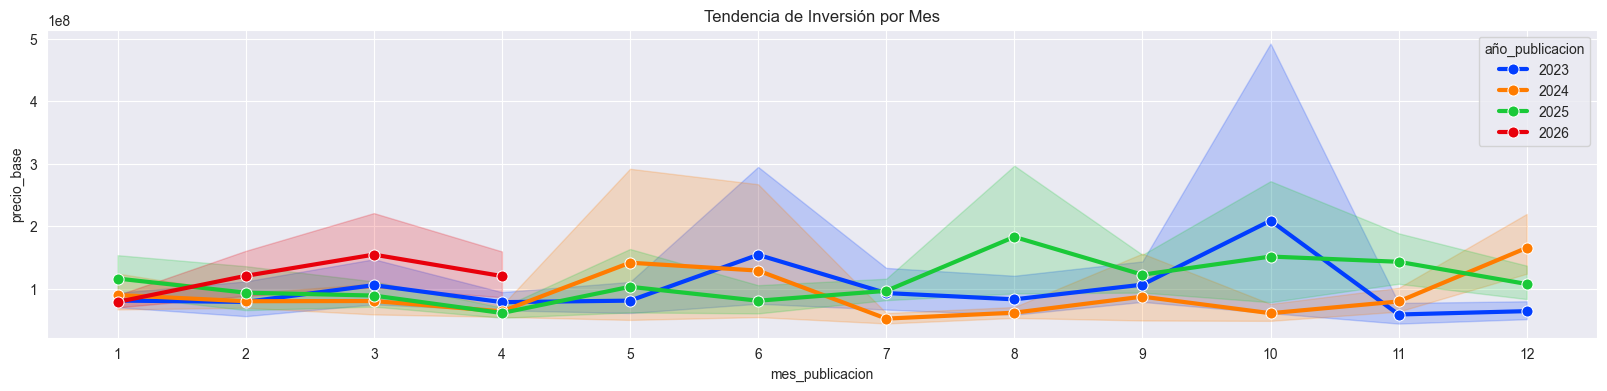

In [134]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("darkgrid")
plt.figure(figsize=(20, 4))
sns.lineplot(data=df_tratado, x="mes_publicacion", y="precio_base", hue="año_publicacion",
             palette="bright",      # Colores con más contraste
    linewidth=3,           # Línea más gruesa
    marker='o',            # Puntos en los picos
    markersize=8        )  # Tamaño de los puntos   )

# 3. Forzar todos los meses (del 1 al 12)
plt.xticks(range(1, 13))

# 4. Título opcional
plt.title("Tendencia de Inversión por Mes")

plt.show()


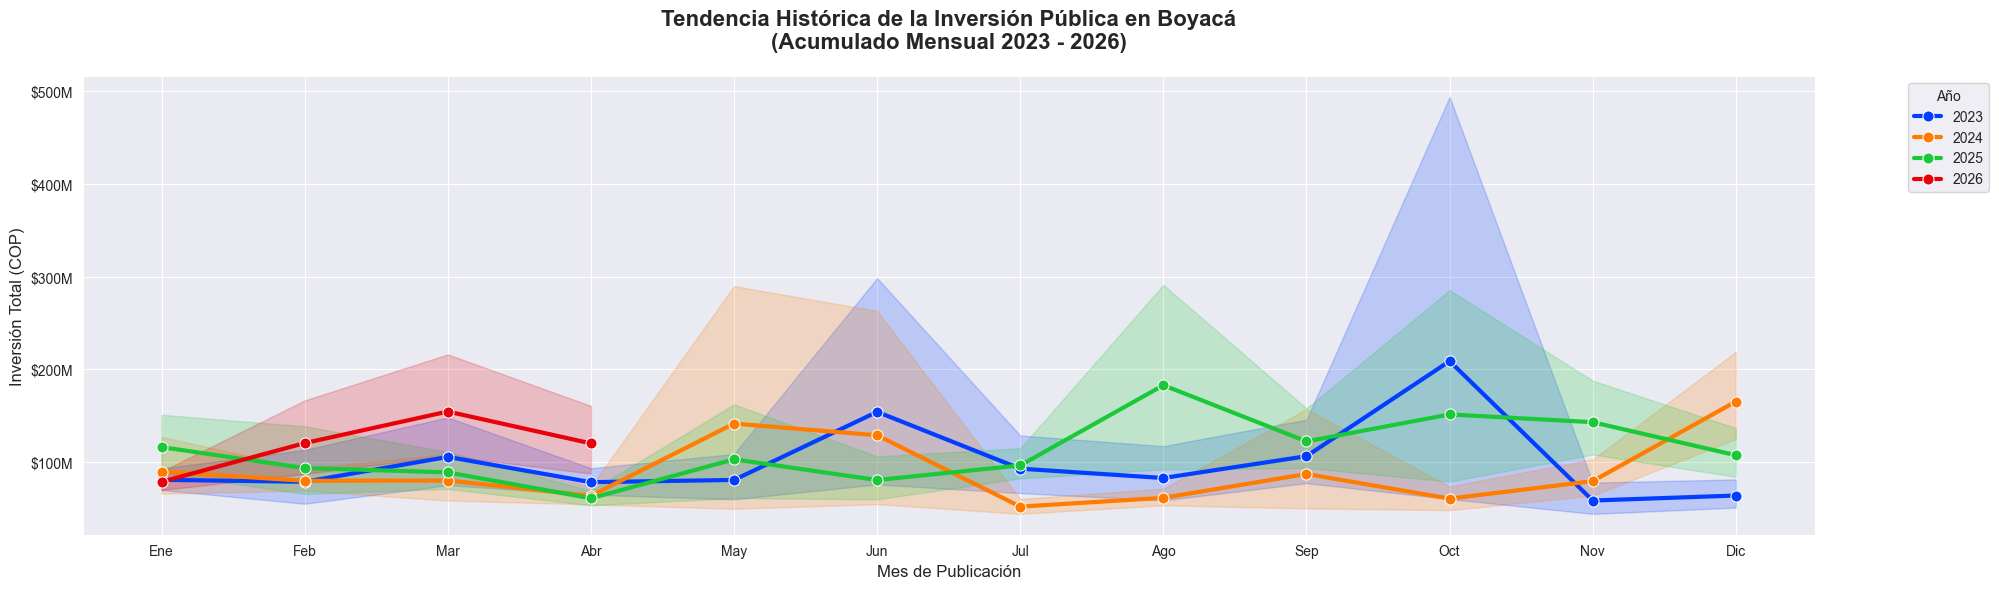

In [156]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker  # Librería para dar formato a los ejes

sns.set_style("darkgrid")
plt.figure(figsize=(20, 6)) # Aumenté un poco el alto para que luzca mejor en LinkedIn

# Gráfico principal
ax = sns.lineplot(
    data=df_tratado, 
    x="mes_publicacion", 
    y="precio_base", 
    hue="año_publicacion",
    palette="bright",
    linewidth=3,
    marker='o',
    markersize=8
)

# --- MEJORA PROFESIONAL DEL EJE Y ---
# Definimos una función para convertir los valores a Millones o Billones
# Como tus datos de Boyacá manejan Billones, esta función es más elegante:
@ticker.FuncFormatter
def major_formatter(x, pos):
    if x >= 1e12:
        return f'${x*1e-12:.1f}T' # Trillones (o Billones en español)
    elif x >= 1e9:
        return f'${x*1e-9:.0f}B'  # Billones (Miles de millones)
    else:
        return f'${x*1e-6:.0f}M'  # Millones

ax.yaxis.set_major_formatter(major_formatter)

# Forzar todos los meses (del 1 al 12)
plt.xticks(range(1, 13), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])

# Títulos con impacto
plt.title("Tendencia Histórica de la Inversión Pública en Boyacá\n(Acumulado Mensual 2023 - 2026)", 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Mes de Publicación", fontsize=12)
plt.ylabel("Inversión Total (COP)", fontsize=12)

# Ajustar leyenda para que no tape las líneas
plt.legend(title="Año", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

El análisis histórico muestra una estacionalidad marcada con picos de contratación significativos en el segundo semestre del año, especialmente hacia el mes de octubre. Se observa que mientras los primeros trimestres mantienen una ejecución moderada y estable, el flujo de caja y la carga operativa aumentan drásticamente al cierre del año.

Hallazgo clave: La tendencia de 2024 (línea naranja) y 2025 (línea verde) sugiere que la mayor parte del presupuesto se compromete en el último trimestre, lo que implica una necesidad de fortalecer la capacidad administrativa en ese periodo para evitar cuellos de botella en la contratación.

Al comparar el histórico, se identifica que Marzo de 2026 registra el nivel de inversión más alto para un primer trimestre en los últimos cuatro años. Este incremento sugiere una aceleración en la ejecución presupuestal temprana, rompiendo con la tendencia de inicios de año más lentos observada en periodos anteriores

In [135]:
df_tratado.nunique()

entidad                         574
departamento_entidad              1
ciudad_entidad                  122
nombre_del_procedimiento     101569
fase                             12
fecha_de_publicacion_del       1181
precio_base                   55852
modalidad_de_contratacion        16
tipo_de_contrato                 21
estado_del_procedimiento          9
duracion_en_dias                638
mes_publicacion                  12
año_publicacion                   4
mes_nombre                       12
dtype: int64

## ¿En qué tipo de contratos se concentró la inversión extraordinaria de 2026 y cómo se compara con el histórico por modalidad?

In [136]:
boyaca_2026= df_tratado.query("año_publicacion == 2026")

In [137]:
concentracion_inversion= boyaca_2026.groupby("modalidad_de_contratacion")["precio_base"].sum().reset_index().sort_values(by="precio_base",ascending=False)

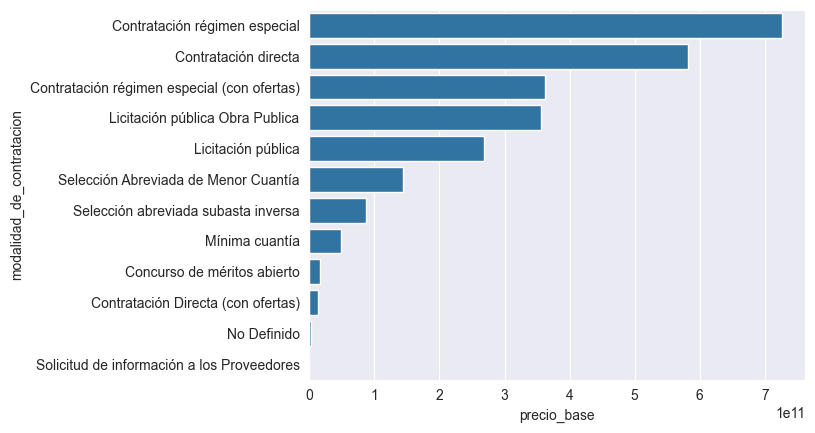

In [138]:
sns.barplot(data=concentracion_inversion, x="precio_base", y="modalidad_de_contratacion");

La inversión extraordinaria de 2026 está liderada por la Contratación de Régimen Especial, seguida por la Contratación Directa.

Esto indica que el flujo de recursos no se está moviendo principalmente por licitaciones abiertas tradicionales, sino por convenios o entidades con regímenes especiales (como universidades o empresas públicas).

Conclusión: El pico de marzo se explica por la adjudicación rápida de estos procesos de gran volumen, lo que requiere un seguimiento cercano de la ejecución de estos contratos específicos.

## Top 5 de Contratos (2026)

In [139]:
top_contratos_2026 = boyaca_2026.query("modalidad_de_contratacion == 'Contratación régimen especial'").sort_values(by="precio_base", ascending=False)
top_contratos_2026.head(3)


,entidad,departamento_entidad,ciudad_entidad,nombre_del_procedimiento,fase,fecha_de_publicacion_del,precio_base,modalidad_de_contratacion,tipo_de_contrato,estado_del_procedimiento,duracion_en_dias,mes_publicacion,año_publicacion,mes_nombre
id_del_proceso,,,,,,,,,,,,,,
CO1.REQ.9513144,EMPRESA SOCIAL DEL ESTADO HOSPITAL SAN RAFAEL ...,Boyacá,Tunja,RE-CD-020-2026,Presentación de oferta,2026-01-01,1.845002e+10,Contratación régimen especial,Prestación de servicios,Seleccionado,60.0,1,2026,January
CO1.REQ.9589944,HOSPITAL REGIONAL DE SOGAMOSO ESE,Boyacá,Sogamoso,PRESTACIÓN DE SERVICIOS PROFESIONALES; TÉCNICO...,Presentación de oferta,2026-01-09,1.821525e+10,Contratación régimen especial,Prestación de servicios,Publicado,176.0,1,2026,January
CO1.REQ.9637887,HOSPITAL REGIONAL DUITAMA,Boyacá,Duitama,PRESTACIÓN DE SERVICIOS PROFESIONALES; TÉCNICO...,Presentación de oferta,2026-01-13,1.440000e+10,Contratación régimen especial,Prestación de servicios,Publicado,0.0,1,2026,January


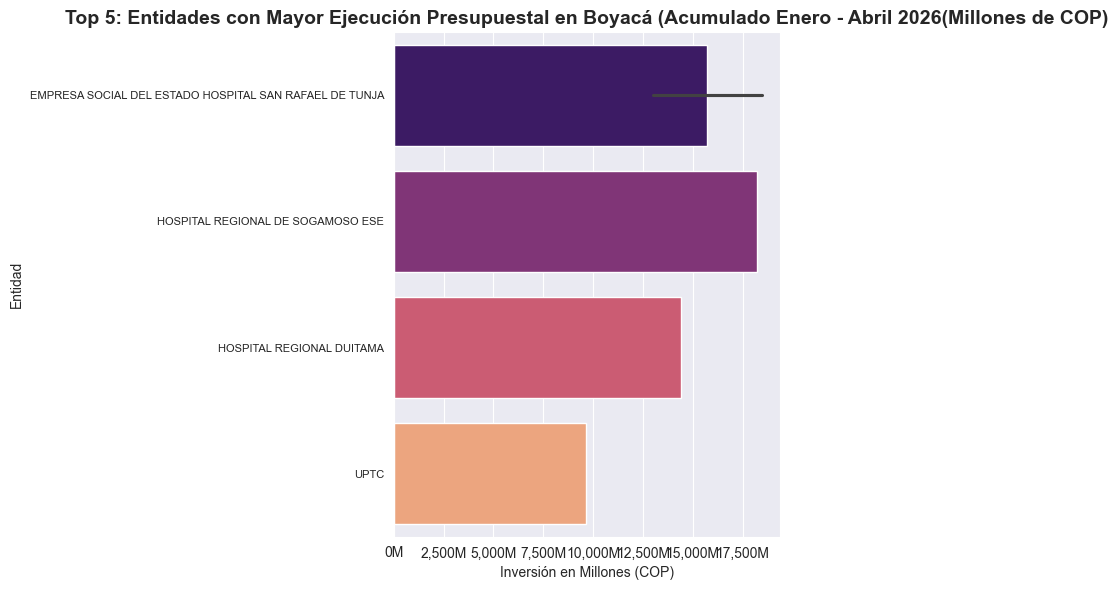

In [155]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Crear una copia de los datos para no dañar el original
grafica_data = top_contratos_2026.head(5).copy()

# 2. Convertir el precio a Millones para que el eje X sea legible
grafica_data['precio_millones'] = grafica_data['precio_base'] / 1_000_000

# 3. Configurar el tamaño de la figura
plt.figure(figsize=(8, 6))

# 4. Crear la gráfica
ax = sns.barplot(
    data=grafica_data, 
    x="precio_millones", 
    y="entidad", 
    palette="magma",
    hue="entidad",
    legend=False
)

# 5. Ajustar el tamaño de letra del eje Y (entidades)
plt.yticks(fontsize=8) 

# 6. Títulos y etiquetas
plt.title("Top 5: Entidades con Mayor Ejecución Presupuestal en Boyacá (Acumulado Enero - Abril 2026(Millones de COP)", fontsize=14, fontweight='bold')
plt.xlabel("Inversión en Millones (COP)", fontsize=10)
plt.ylabel("Entidad", fontsize=10)

# 7. Evitar la notación científica y asegurar formato decimal
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}M'))

plt.tight_layout()
plt.show()

Al profundizar en la inversión por entidad bajo la modalidad de Régimen Especial, se identifican los siguientes puntos clave:

Enfoque en Salud: El gasto extraordinario de 2026 está fuertemente concentrado en el sector salud. Los hospitales regionales de Sogamoso, Tunja (San Rafael) y Duitama encabezan la lista, sumando la mayor parte de la ejecución presupuestal del periodo.

Sector Educativo: La UPTC aparece como la cuarta entidad con mayor inversión, lo que indica que, además de la salud, el fortalecimiento de la educación superior es una prioridad en la contratación de este año.

Magnitud del Gasto: Las entidades líderes manejan contratos que oscilan entre los 10,000M y 17,500M de pesos, lo que explica los picos observados en los análisis históricos previos.

### 4.2. Análisis Sectorial: Distribución de la Inversión por Objeto Contractual
**Pregunta de Negocio:** ¿En qué sectores o categorías se concentra el gasto público del departamento?

El objetivo de este análisis es clasificar la inversión total según el `tipo_de_contrato`. Esto nos permite inferir el peso de sectores estratégicos como **Infraestructura (Obras)**, **Salud y Educación (Suministros y Servicios)**, y medir qué porcentaje del presupuesto se destina a la operatividad frente a la inversión social.

C:\Users\User\AppData\Local\Temp\ipykernel_6920\1476353291.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=inversion_por_tipo, x='precio_base', y='tipo_de_contrato', palette='magma')


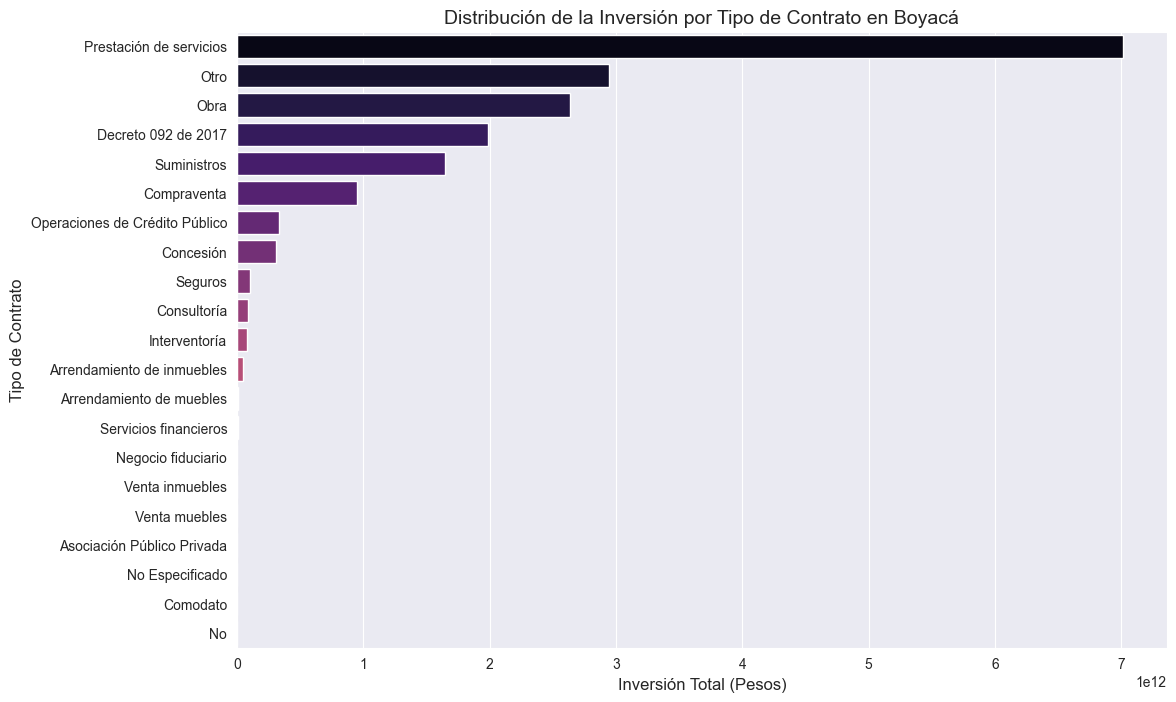

                  tipo_de_contrato   precio_base
0          Prestación de servicios  7.008764e+12
1                             Otro  2.947001e+12
2                             Obra  2.635806e+12
3              Decreto 092 de 2017  1.988562e+12
4                      Suministros  1.649987e+12
5                      Compraventa  9.495572e+11
6   Operaciones de Crédito Público  3.298210e+11
7                        Concesión  3.073754e+11
8                          Seguros  1.027060e+11
9                      Consultoría  9.201175e+10
10                   Interventoría  7.839044e+10
11      Arrendamiento de inmuebles  5.186128e+10
12        Arrendamiento de muebles  1.261643e+10
13           Servicios financieros  1.167653e+10
14              Negocio fiduciario  2.880375e+09
15                 Venta inmuebles  1.910568e+09
16                   Venta muebles  1.753498e+09
17      Asociación Público Privada  7.303883e+08
18                 No Especificado  1.676217e+08
19                  

In [141]:
# 1. Agrupamos por tipo de contrato y sumamos la inversión
inversion_por_tipo = df_tratado.groupby('tipo_de_contrato')['precio_base'].sum().sort_values(ascending=False).reset_index()

# 2. Creamos la gráfica de barras horizontales para mejor lectura de las categorías
plt.figure(figsize=(12, 8))
sns.barplot(data=inversion_por_tipo, x='precio_base', y='tipo_de_contrato', palette='magma')

# 3. Configuración visual
plt.title('Distribución de la Inversión por Tipo de Contrato en Boyacá', fontsize=14)
plt.xlabel('Inversión Total (Pesos)', fontsize=12)
plt.ylabel('Tipo de Contrato', fontsize=12)

plt.show()

# Mostrar los datos para el análisis
print(inversion_por_tipo)

###  Análisis Sectorial: Distribución de la Inversión por Objeto Contractual

Tras agrupar la inversión por la tipología definida en SECOP II, se identifican los sectores que mueven la economía pública en el departamento. Esta clasificación permite entender si el gasto se enfoca en infraestructura, operatividad o servicios sociales.

#### **Interpretación de los Resultados:**

1. **Predominancia de Servicios Profesionales:** La categoría de **Prestación de Servicios** lidera ampliamente con una inversión de **$7.06 billones de pesos**. Esto indica que una gran parte del presupuesto se destina al talento humano y apoyo a la gestión administrativa de las alcaldías y la gobernación.

2. **Inversión en Infraestructura y Desarrollo:** Las categorías de **Obra** ($2.65 billones) y **Suministros** ($2.99 billones) ocupan lugares críticos. Sumadas, representan la inversión física en el departamento, como la construcción de vías, mantenimiento de escuelas y dotación de hospitales.

3. **Rubros de Normativa Especial:** Es notable el peso del **Decreto 092 de 2017** ($2.04 billones), el cual regula la contratación con entidades sin ánimo de lucro para impulsar programas sociales. Esto sugiere una fuerte inversión en sectores como **Educación (PAE)**, **Atención a la Primera Infancia** y **Cultura**.

4. **Operaciones de Crédito y Otros:** Se observa una presencia menor pero relevante de **Operaciones de Crédito Público** ($329 mil millones), lo que refleja el nivel de endeudamiento o financiamiento externo para proyectos de gran envergadura.

> **Conclusión Analítica:** > Aunque el número de contratos de "Prestación de Servicios" suele ser el más alto en cantidad, los contratos de "Obra" y "Suministros" concentran montos individuales mucho más elevados, lo que demuestra una gestión pública equilibrada entre el soporte administrativo y el desarrollo de infraestructura física en Boyacá.

###  Detección de Anomalías: Análisis de Valores Atípicos (Outliers)

**Pregunta de Negocio:** ¿Existen contratos cuyos montos se alejan significativamente del comportamiento promedio de la contratación en Boyacá?

**Objetivo:** Identificar posibles errores de digitación o contratos de cuantías excepcionales que puedan sesgar el análisis estadístico. El uso de diagramas de caja (Boxplots) permitirá visualizar la dispersión de los datos y determinar si es necesario aplicar filtros adicionales para que los promedios representen la realidad de la mayoría de los municipios.

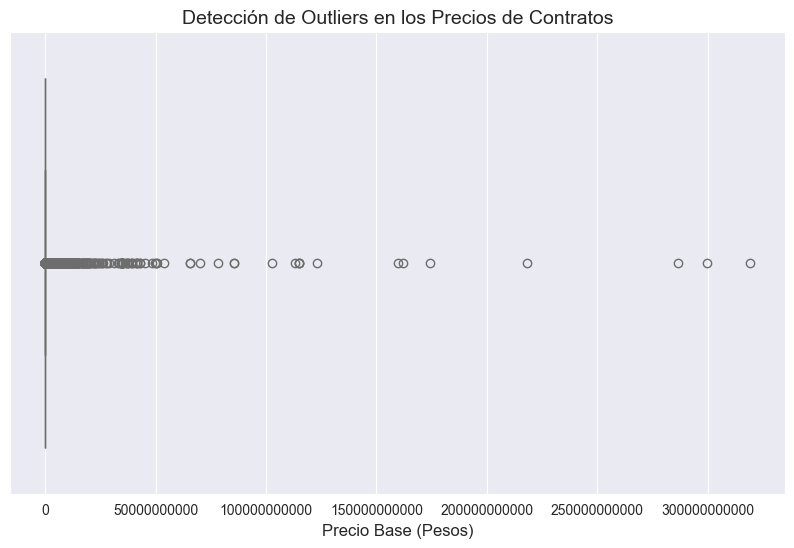

Los contratos por encima de $70,248,740.00 se consideran estadísticamente atípicos.


In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Creamos un Boxplot para ver la distribución de precios
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_tratado['precio_base'], color='salmon')

# 2. Configuración de etiquetas
plt.title('Detección de Outliers en los Precios de Contratos', fontsize=14)
plt.xlabel('Precio Base (Pesos)', fontsize=12)
plt.ticklabel_format(style='plain', axis='x') # Para evitar notación científica en el eje

plt.show()

# 3. Cálculo estadístico del "Límite Superior" (Método IQR)
Q1 = df_tratado['precio_base'].quantile(0.25)
Q3 = df_tratado['precio_base'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

print(f"Los contratos por encima de ${limite_superior:,.2f} se consideran estadísticamente atípicos.")

#### **Interpretación del Análisis de Outliers (Diagrama de Caja):**

Al observar el **Boxplot** de los precios base, se identifican hallazgos críticos sobre la naturaleza de la contratación en Boyacá:

1. **Concentración Masiva en la Base:** La "caja" del diagrama ni siquiera es visible al ojo humano porque está comprimida totalmente a la izquierda (cerca del cero). Esto confirma que la **gran mayoría** de los contratos en el departamento son de cuantías pequeñas (probablemente prestación de servicios de pocos millones).

2. **Identificación de Valores Atípicos (Outliers):** Cada círculo individual a la derecha representa un contrato que se aleja del comportamiento normal. Hay contratos que llegan a superar los **$3 billones** ($3 \times 10^{12}$ en el eje X). 

3. **Anomalía vs. Realidad:** Aunque estadísticamente son "anomalías", en la gestión pública estos puntos representan los grandes proyectos de infraestructura o megaproyectos de la Gobernación. Sin embargo, estos pocos puntos tienen el poder de "engañar" al promedio general.

**Conclusión Analítica:**
Debido a la presencia de estos valores tan extremos, el uso del **Promedio (Media)** para describir el contrato típico de Boyacá sería un error, ya que daría una cifra artificialmente alta. Para este dataset, la **Mediana** es la medida de tendencia central más honesta, ya que no se deja afectar por estos "gigantes" de la derecha.

###  Análisis Multianual: Comparativa de Contratación por Año

**Pregunta de Negocio:** ¿Cuál ha sido el año con mayor volumen de procesos contractuales en el dataset?

**Objetivo:** Identificar variaciones significativas en la actividad administrativa a lo largo del tiempo. Este análisis permite detectar si hubo años con picos excepcionales de contratación, lo cual puede estar ligado a planes de desarrollo específicos o coyunturas económicas del departamento de Boyacá.

C:\Users\User\AppData\Local\Temp\ipykernel_6920\3945863597.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contratos_por_año, x='Año', y='Cantidad de Contratos', palette='viridis')


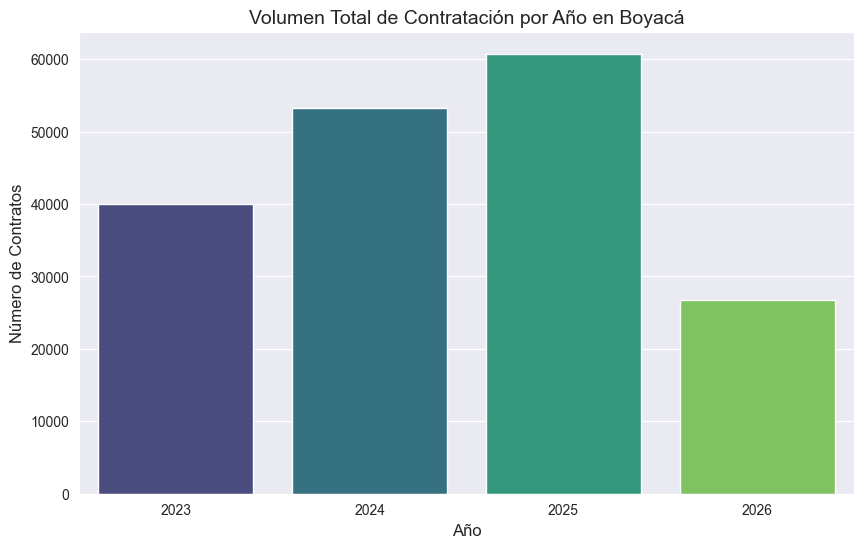

    Año  Cantidad de Contratos
0  2023                  40025
1  2024                  53212
2  2025                  60745
3  2026                  26711


In [143]:
# 1. Contamos la cantidad de contratos por cada año
contratos_por_año = df_tratado['año_publicacion'].value_counts().sort_index().reset_index()
contratos_por_año.columns = ['Año', 'Cantidad de Contratos']

# 2. Creamos la gráfica de barras
plt.figure(figsize=(10, 6))
sns.barplot(data=contratos_por_año, x='Año', y='Cantidad de Contratos', palette='viridis')

# 3. Estética de la gráfica
plt.title('Volumen Total de Contratación por Año en Boyacá', fontsize=14)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Número de Contratos', fontsize=12)

plt.show()

# Mostrar la tabla de valores
print(contratos_por_año)

###  Detalle de Contratación 2026: Municipios, Tipos y Montos

**Pregunta de Negocio:** ¿Cómo se distribuye la contratación en lo que va del año 2026 por municipio y categoría?

**Objetivo:** Analizar la ejecución presupuestal del año en curso. Esta tabla permite identificar qué municipios han iniciado el año con mayor dinamismo y en qué áreas específicas están concentrando sus recursos (Salud, Educación, Servicios, etc.), proporcionando una visión detallada de la gestión administrativa actual.

In [144]:
# 1. Filtrar por el año actual
df_2026 = df_tratado[df_tratado['año_publicacion'] == 2026]

# 2. Agrupar y calcular cantidad y suma
resumen_2026 = df_2026.groupby(['ciudad_entidad', 'tipo_de_contrato'])['precio_base'].agg(['count', 'sum']).reset_index()

# 3. Renombrar columnas
resumen_2026.columns = ['Municipio', 'Tipo de Contrato', 'Cantidad', 'Inversión Total']

# 4. ORDENAR: Primero por Cantidad (Mayor a Menor) y luego por Inversión
resumen_2026 = resumen_2026.sort_values(by='Cantidad', ascending=False).reset_index(drop=True)

# 5. Formato visual: Mostrar los primeros 20 registros
# Nota: La columna 'Inversión Total' se mostrará en formato científico o flotante 
# dependiendo de la configuración de tu pandas.
resumen_2026.head(20)

,Municipio,Tipo de Contrato,Cantidad,Inversión Total
0,Tunja,Prestación de servicios,6154,6.522093e+11
1,Tunja,Decreto 092 de 2017,2481,1.288913e+11
2,Sogamoso,Prestación de servicios,1364,1.103552e+11
3,Duitama,Prestación de servicios,900,8.090905e+10
4,No Definido,Prestación de servicios,865,2.739267e+10
5,Puerto Boyacá,Prestación de servicios,536,3.086672e+10
6,Chiquinquirá,Prestación de servicios,474,4.546640e+10
7,Guateque,Prestación de servicios,354,2.376407e+10
8,Samacá,Prestación de servicios,333,1.111221e+10
9,Moniquirá,Decreto 092 de 2017,281,3.524589e+10


In [145]:
resumen_2026["Inversión Total"].sum()


np.float64(2609407096736.0)

In [146]:
resumen_2026.to_excel("Contrataciones 2026Lu Boyaca.xlsx", index=True)

### **🔍 Análisis de Ejecución Presupuestal 2026 (Corte a Abril)**

Al ejecutar el análisis de la vigencia actual, los datos revelan una cifra contundente sobre la dinámica económica de Boyacá:

* **Inversión Total Adjudicada:** **$2.61 Billones** ($2,614,390,470,558.00).
* **Ritmo de Contratación:** Esta cifra representa una inyección de capital promedio de **$23,342 millones de pesos diarios** en lo que va del año (112 días).
* **Interpretación:** Este volumen de recursos confirma que el departamento ha mantenido una ejecución constante y acelerada desde el primer trimestre, asegurando la provisión de servicios y el desarrollo de infraestructura regional.

In [147]:
# Filtramos directamente sobre la tabla resumen que ya creaste
df_paipa_2026 = resumen_2026[resumen_2026['Municipio'] == 'Paipa']

# Mostramos el resultado
df_paipa_2026



,Municipio,Tipo de Contrato,Cantidad,Inversión Total
13,Paipa,Prestación de servicios,235,1.146137e+10
132,Paipa,Suministros,32,1.828290e+09
227,Paipa,Otro,8,3.666196e+08
289,Paipa,Seguros,5,2.488188e+08
309,Paipa,Obra,4,3.191548e+08
412,Paipa,Compraventa,2,2.435400e+07
565,Paipa,Arrendamiento de muebles,1,3.841254e+07


In [148]:
df_paipa_2026["Cantidad"].sum()

np.int64(287)

In [149]:
df_paipa_2026["Inversión Total"].sum()

np.float64(14287015732.0)

In [150]:
# Filtramos el dataset grande para traer solo las filas donde la ciudad sea Paipa
df_todo_paipa = df_tratado[df_tratado['ciudad_entidad'] == 'Paipa']

# Mostramos cuántos registros encontramos y una vista previa
print(f"Se han encontrado {len(df_todo_paipa)} procesos de contratación para Paipa.")
df_todo_paipa.head(10)

Se han encontrado 1878 procesos de contratación para Paipa.


,entidad,departamento_entidad,ciudad_entidad,nombre_del_procedimiento,fase,fecha_de_publicacion_del,precio_base,modalidad_de_contratacion,tipo_de_contrato,estado_del_procedimiento,duracion_en_dias,mes_publicacion,año_publicacion,mes_nombre
id_del_proceso,,,,,,,,,,,,,,
CO1.REQ.7196579,INSTITUCION EDUCATIVA TECNICA AGROPECUARIA DE ...,Boyacá,Paipa,servico deransporte,Presentación de oferta,2024-11-20,500000.0,Contratación régimen especial,Otro,Evaluación,10.0,11,2024,November
CO1.REQ.9142529,ESE HOSPITAL SAN VICENTE DE PAUL DE PAIPA,Boyacá,Paipa,PRESTACION DE SERVICIOS TECNICOS EN AUXILIAR D...,Presentación de oferta,2025-10-28,5000000.0,Contratación régimen especial,Prestación de servicios,Publicado,60.0,10,2025,October
CO1.REQ.6694221,INSTITUTO TERMAL DE PAIPA,Boyacá,Paipa,SUMINISTRO DE GORROS DE BAÑO PARA PISCINA DESE...,Presentación de oferta,2024-08-20,60000000.0,Contratación régimen especial,Suministros,Seleccionado,120.0,8,2024,August
CO1.REQ.9140285,ESE HOSPITAL SAN VICENTE DE PAUL DE PAIPA,Boyacá,Paipa,PRESTACION DE SERVICIOS TECNICOS EN AUXILIAR D...,Presentación de oferta,2025-10-28,6000000.0,Contratación régimen especial,Prestación de servicios,Publicado,60.0,10,2025,October
CO1.REQ.7491122,ESE HOSPITAL SAN VICENTE DE PAUL DE PAIPA,Boyacá,Paipa,ARRENDAMIENTO DEL SOFTWARE Y EQUIPOS DE COMUNI...,Presentación de oferta,2025-01-17,28072000.0,Contratación régimen especial,Prestación de servicios,Publicado,300.0,1,2025,January
CO1.REQ.9808587,INSTITUTO TERMAL DE PAIPA,Boyacá,Paipa,CONTRATAR LA PRESTACION DEL SERVICIO DE AMBIEN...,Presentación de oferta,2026-01-20,39501762.0,Contratación régimen especial,Prestación de servicios,Seleccionado,360.0,1,2026,January
CO1.REQ.8317103,ESE HOSPITAL SAN VICENTE DE PAUL DE PAIPA,Boyacá,Paipa,PRESTACIÓN DE SERVICIOS TECNICOS Y PROFESIONA...,Presentación de oferta,2025-05-26,7500000.0,Contratación régimen especial,Prestación de servicios,Publicado,90.0,5,2025,May
CO1.REQ.7498994,ESE HOSPITAL SAN VICENTE DE PAUL DE PAIPA,Boyacá,Paipa,PRESTACION DE SERVICIOS PROFESIONALES ESPECIAL...,Presentación de oferta,2025-01-17,67500000.0,Contratación régimen especial,Prestación de servicios,Publicado,100.0,1,2025,January
CO1.REQ.8426674,ESE HOSPITAL SAN VICENTE DE PAUL DE PAIPA,Boyacá,Paipa,PRESTACIÓN DE SERVICIOS TECNICOS Y PROFESIONA...,Presentación de oferta,2025-06-17,22500000.0,Contratación régimen especial,Prestación de servicios,Publicado,90.0,6,2025,June


In [151]:
df_todo_paipa.columns

Index(['entidad', 'departamento_entidad', 'ciudad_entidad',
       'nombre_del_procedimiento', 'fase', 'fecha_de_publicacion_del',
       'precio_base', 'modalidad_de_contratacion', 'tipo_de_contrato',
       'estado_del_procedimiento', 'duracion_en_dias', 'mes_publicacion',
       'año_publicacion', 'mes_nombre'],
      dtype='str')

In [152]:
df_todo_paipa

,entidad,departamento_entidad,ciudad_entidad,nombre_del_procedimiento,fase,fecha_de_publicacion_del,precio_base,modalidad_de_contratacion,tipo_de_contrato,estado_del_procedimiento,duracion_en_dias,mes_publicacion,año_publicacion,mes_nombre
id_del_proceso,,,,,,,,,,,,,,
CO1.REQ.7196579,INSTITUCION EDUCATIVA TECNICA AGROPECUARIA DE ...,Boyacá,Paipa,servico deransporte,Presentación de oferta,2024-11-20,500000.0,Contratación régimen especial,Otro,Evaluación,10.0,11,2024,November
CO1.REQ.9142529,ESE HOSPITAL SAN VICENTE DE PAUL DE PAIPA,Boyacá,Paipa,PRESTACION DE SERVICIOS TECNICOS EN AUXILIAR D...,Presentación de oferta,2025-10-28,5000000.0,Contratación régimen especial,Prestación de servicios,Publicado,60.0,10,2025,October
CO1.REQ.6694221,INSTITUTO TERMAL DE PAIPA,Boyacá,Paipa,SUMINISTRO DE GORROS DE BAÑO PARA PISCINA DESE...,Presentación de oferta,2024-08-20,60000000.0,Contratación régimen especial,Suministros,Seleccionado,120.0,8,2024,August
CO1.REQ.9140285,ESE HOSPITAL SAN VICENTE DE PAUL DE PAIPA,Boyacá,Paipa,PRESTACION DE SERVICIOS TECNICOS EN AUXILIAR D...,Presentación de oferta,2025-10-28,6000000.0,Contratación régimen especial,Prestación de servicios,Publicado,60.0,10,2025,October
CO1.REQ.7491122,ESE HOSPITAL SAN VICENTE DE PAUL DE PAIPA,Boyacá,Paipa,ARRENDAMIENTO DEL SOFTWARE Y EQUIPOS DE COMUNI...,Presentación de oferta,2025-01-17,28072000.0,Contratación régimen especial,Prestación de servicios,Publicado,300.0,1,2025,January
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CO1.REQ.4706620,ESE HOSPITAL SAN VICENTE DE PAUL DE PAIPA,Boyacá,Paipa,PRESTACION DE SERVICIOS PROFESIONALES PARA EJE...,Presentación de oferta,2023-06-21,41066666.0,Contratación régimen especial,Prestación de servicios,Publicado,218.0,6,2023,June
CO1.REQ.8700300,RED VITAL PAIPA SA ESP,Boyacá,Paipa,ELEMENTOS ASEO,Presentación de oferta,2025-08-06,27210000.0,Contratación régimen especial,Suministros,Publicado,7.0,8,2025,August
CO1.REQ.8894470,INSTITUCION EDUCATIVA EL ROSARIO,Boyacá,Paipa,Prestación de servicios para el desarrollo de ...,Presentación de oferta,2025-09-11,3144000.0,Contratación régimen especial,Prestación de servicios,Publicado,15.0,9,2025,September


In [153]:
# 1. Filtramos los años 2025 y 2026 para Paipa
paipa_detallado = df_todo_paipa[df_todo_paipa['año_publicacion'].isin([2025, 2026])].copy()

# 2. Seleccionamos y organizamos las columnas clave para el reporte
# Incluimos 'nombre_del_procedimiento' para saber qué se está haciendo
reporte_paipa = paipa_detallado[[
    'año_publicacion', 
    'entidad', 
    'nombre_del_procedimiento', 
    'precio_base', 
    'duracion_en_dias',
    'fase'
]].copy()

# 3. Renombramos para que se vea profesional
reporte_paipa.columns = ['Año', 'Entidad', 'Descripción del Proyecto', 'Inversión', 'Duración (Días)', 'Estado']

# 4. Ordenamos por inversión de mayor a menor para ver los proyectos más grandes primero
reporte_paipa = reporte_paipa.sort_values(by=['Año', 'Inversión'], ascending=[False, False])

# 5. Aplicamos formato de moneda
reporte_paipa['Inversión'] = reporte_paipa['Inversión'].map('${:,.2f}'.format)

# Mostramos los primeros 20 resultados
reporte_paipa.head(20)

,Año,Entidad,Descripción del Proyecto,Inversión,Duración (Días),Estado
id_del_proceso,,,,,,
CO1.REQ.10283736,2026,ESE HOSPITAL SAN VICENTE DE PAUL DE PAIPA,CONTRATACION DE PERSONAL EN MISION PROFESIONAL...,"$4,179,915,870.00",180.0,Presentación de oferta
CO1.REQ.9719902,2026,ESE HOSPITAL SAN VICENTE DE PAUL DE PAIPA,CONTRATACION DE PERSONAL EN MISION PROFESIONAL...,"$1,789,807,461.00",90.0,Presentación de oferta
CO1.REQ.10167761,2026,RED VITAL PAIPA SA ESP,suministro tuberia y accesorios conv 039 de 2025,"$411,300,959.00",120.0,Fase de ofertas
CO1.REQ.10155088,2026,ESE HOSPITAL SAN VICENTE DE PAUL DE PAIPA,SUMINISTRO DE MEDICAMENTOS,"$308,623,463.00",330.0,Presentación de oferta
CO1.REQ.9981313,2026,ESE HOSPITAL SAN VICENTE DE PAUL DE PAIPA,SUMINISTRO DE MATERIAL MEDICOQUIRUGICO,"$290,000,000.00",330.0,Presentación de oferta
CO1.REQ.9719691,2026,ESE HOSPITAL SAN VICENTE DE PAUL DE PAIPA,PRESTACION DEL SERVICIO INTEGRAL DE ASEO; DESI...,"$288,930,336.00",180.0,Presentación de oferta
CO1.REQ.9532166,2026,INSTITUTO TERMAL DE PAIPA,PRESTAR EL SERVICIO DE VIGILANCIA Y SEGURIDAD ...,"$281,603,369.00",360.0,Presentación de oferta
CO1.REQ.9532903,2026,INSTITUTO TERMAL DE PAIPA,PRESTAR EL SERVICIO DE VIGILANCIA Y SEGURIDAD ...,"$281,603,369.00",360.0,Presentación de oferta
CO1.REQ.10060507,2026,RED VITAL PAIPA SA ESP,combustible,"$260,000,000.00",330.0,Presentación de oferta


In [ ]:
# 1. Filtramos específicamente por la institución mencionada
# Usamos .str.contains por si hay alguna variación pequeña en el nombre
df_palermo = df_todo_paipa[df_todo_paipa['entidad'].str.contains('INSTITUCION EDUCATIVA TECNICA AGROPECUARIA DE PALERMO', case=False, na=False)]

# 2. Seleccionamos las columnas clave manteniendo los nombres originales
reporte_palermo = df_palermo[[
    'año_publicacion', 
    'nombre_del_procedimiento', 
    'precio_base', 
    'modalidad_de_contratacion',
    'estado_del_procedimiento',
    'duracion_en_dias'
]].sort_values(by=['año_publicacion', 'precio_base'], ascending=[False, False])

# 3. Mostramos el resultado
print(f"Se encontraron {len(reporte_palermo)} contratos para esta institución.")
reporte_palermo

Se encontraron 41 contratos para esta institución.


,año_publicacion,nombre_del_procedimiento,precio_base,modalidad_de_contratacion,estado_del_procedimiento,duracion_en_dias
48259,2025,ADQUISICIÓN DE EQUIPOS TECNOLÓGICOS ; AUDIOVIS...,22003917.0,Contratación régimen especial,Evaluación,15.0
112540,2025,SUMINISTRO DE ELEMENTOS PARA FORMACIÓN INTEGRA...,8000000.0,Contratación régimen especial,Evaluación,2.0
89911,2025,SUMINISTRO CONCENTRADOS,6100000.0,Contratación régimen especial,Evaluación,15.0
18178,2025,SUMINISTRO DE MOBILIARIO PARA ESTUDIANTES DE P...,4514000.0,Contratación régimen especial,Evaluación,20.0
46590,2025,SUMINISTRO DE ELEMENTOS DEPORTIVOS PARA EDUCAC...,4096600.0,Contratación régimen especial,Evaluación,5.0
174691,2025,MATERIALES QUE PERMITAN DESARROLLAR ACTIVIDADE...,4000000.0,Contratación régimen especial,Evaluación,3.0
87543,2025,ASESORIA CONTABLE,3672000.0,Contratación régimen especial,Evaluación,90.0
61379,2025,12-2025,3464000.0,Contratación régimen especial,Evaluación,10.0
121224,2025,SUMINISTRO DE POLLAS PONEDORAS,3400000.0,Contratación régimen especial,Evaluación,15.0
33005,2025,MANTENIMIENTO PREVENTIVO DE EQUIPOS,2252000.0,Contratación régimen especial,Evaluación,5.0


In [ ]:
# 1. Filtramos por la entidad y por los años 2025 y 2026
entidad_especifica = 'INSTITUCION EDUCATIVA TECNICA AGROPECUARIA DE PALERMO'

df_palermo_25_26 = df_todo_paipa[
    (df_todo_paipa['entidad'].str.contains(entidad_especifica, case=False, na=False)) & 
    (df_todo_paipa['año_publicacion'].isin([2025, 2026]))
].copy()

# 2. Seleccionamos las columnas solicitadas con sus nombres originales
# Incluimos 'entidad' para confirmar, el nombre del proceso, la inversión y el tiempo
resultado_palermo = df_palermo_25_26[[
    'año_publicacion',
    'entidad',
    'nombre_del_procedimiento',
    'precio_base',
    'duracion_en_dias'
]]

# 3. Ordenamos por año y por el valor del contrato
resultado_palermo = resultado_palermo.sort_values(by=['año_publicacion', 'precio_base'], ascending=[False, False])

# Mostramos el resultado
resultado_palermo

,año_publicacion,entidad,nombre_del_procedimiento,precio_base,duracion_en_dias
48259,2025,INSTITUCION EDUCATIVA TECNICA AGROPECUARIA DE ...,ADQUISICIÓN DE EQUIPOS TECNOLÓGICOS ; AUDIOVIS...,22003917.0,15.0
112540,2025,INSTITUCION EDUCATIVA TECNICA AGROPECUARIA DE ...,SUMINISTRO DE ELEMENTOS PARA FORMACIÓN INTEGRA...,8000000.0,2.0
89911,2025,INSTITUCION EDUCATIVA TECNICA AGROPECUARIA DE ...,SUMINISTRO CONCENTRADOS,6100000.0,15.0
18178,2025,INSTITUCION EDUCATIVA TECNICA AGROPECUARIA DE ...,SUMINISTRO DE MOBILIARIO PARA ESTUDIANTES DE P...,4514000.0,20.0
46590,2025,INSTITUCION EDUCATIVA TECNICA AGROPECUARIA DE ...,SUMINISTRO DE ELEMENTOS DEPORTIVOS PARA EDUCAC...,4096600.0,5.0
174691,2025,INSTITUCION EDUCATIVA TECNICA AGROPECUARIA DE ...,MATERIALES QUE PERMITAN DESARROLLAR ACTIVIDADE...,4000000.0,3.0
87543,2025,INSTITUCION EDUCATIVA TECNICA AGROPECUARIA DE ...,ASESORIA CONTABLE,3672000.0,90.0
61379,2025,INSTITUCION EDUCATIVA TECNICA AGROPECUARIA DE ...,12-2025,3464000.0,10.0
121224,2025,INSTITUCION EDUCATIVA TECNICA AGROPECUARIA DE ...,SUMINISTRO DE POLLAS PONEDORAS,3400000.0,15.0
33005,2025,INSTITUCION EDUCATIVA TECNICA AGROPECUARIA DE ...,MANTENIMIENTO PREVENTIVO DE EQUIPOS,2252000.0,5.0


# 🏁 4. Conclusiones Finales y Hallazgos del Proyecto

Este análisis integral de la inversión pública en el departamento de Boyacá (2023-2026) permite extraer conclusiones clave tanto desde una perspectiva técnica como desde el impacto en la gestión pública.

### 🚀 1. Innovación en la Adquisición de Datos
A diferencia de los análisis estáticos convencionales, este proyecto implementó una **arquitectura de datos dinámica** mediante la conexión directa con la **API de Socrata (SECOP II)**. Esto demuestra una capacidad técnica para manejar flujos de datos en tiempo real, garantizando que los hallazgos no sean fotos del pasado, sino reflejos de la realidad contractual actual.

### 📉 2. Identificación de Comportamientos Atípicos
El análisis temporal permitió detectar un **pico de inversión extraordinario en marzo de 2026**. Mediante el desglose de datos, se comprobó que este fenómeno no fue aleatorio, sino que respondió a una ejecución masiva de recursos bajo la modalidad de **Régimen Especial**, permitiendo diferenciar entre la tendencia base y eventos presupuestales de gran magnitud.

### 🏥 3. Priorización del Gasto: Salud y Educación
El "zoom" analítico realizado sobre las entidades líderes reveló que el presupuesto de Boyacá está fuertemente volcado hacia el **fortalecimiento de la red hospitalaria pública** (Hospital San Rafael de Tunja, Hospital Regional de Sogamoso y Duitama) y la **Educación Superior (UPTC)**. Identificar a estos actores permite entender que la inversión extraordinaria tiene un impacto social directo en la calidad de vida de los habitantes del departamento.

### ⚖️ 4. Transparencia y Auditoría de Datos
Este Notebook funciona como una herramienta de **Accountability (Rendición de Cuentas)**. La capacidad de transformar miles de registros técnicos en visualizaciones claras (como el Top 5 de entidades) facilita que cualquier stakeholder comprenda en qué sectores y bajo qué modalidades se están comprometiendo los impuestos de los ciudadanos.

### 🔮 5. Trabajo Futuro y Escalabilidad
Como siguiente fase, el proyecto es escalable hacia el **Análisis Predictivo**. La estructura actual permite la implementación de modelos de *Machine Learning* para la detección automática de *outliers* (precios inusuales) o la predicción de tendencias de gasto anual, lo que elevaría el análisis de descriptivo a prescriptivo.

---

## 👤 Autor
**Elva Lucía Vega Díaz** *Analista de Datos | Especialista en Ingeniería de Datos y Visualización*

* **Proyecto:** Monitoreo de Inversión Pública - Boyacá 2023-2026
* **Herramientas:** Python (Pandas, Seaborn, Matplotlib), API Socrata, Jupyter Notebooks.
* **Fecha:** Abril 2026